# วิเคราะห์ข้อมูลการนำเข้า–ส่งออกสินค้าประมงของไทย
ข้อมูลจากระบบบัญชีข้อมูลภาครัฐ (Government Open Data)

ข้อมูลปี พ.ศ. 2568 (เดือน ม.ค. — ธ.ค.)

import library ต่างๆ

In [242]:
import polars as pl
import numpy as np
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from IPython.display import display, HTML


import warnings
warnings.filterwarnings('ignore')

### โหลดและสำรวจข้อมูลเบื้องต้น

In [243]:
# เก็บข้อมูล raw data ไว้ที่ data
data = pl.read_csv('import_export.csv', infer_schema_length=5000)

In [244]:
# print ข้อมูลมาดูคร่าวๆ
print(f'ขนาดข้อมูล: {data.shape[0]:,} แถว x {data.shape[1]} คอลัมน์')
data.head(5)

ขนาดข้อมูล: 42,057 แถว x 12 คอลัมน์


year,month,heading11,countryID,countryNameTH,weight,quantity,price,tradeflow,productDetailEN,productDetailTH,ETL_DATE
i64,i64,i64,str,str,i64,i64,i64,i64,str,str,str
2568,8,1062000002,"""BJ""","""เบนิน""",33,90,48080,1,"""Turtles and snapping turtles l…","""เต่าและตะพาบน้ำมีชีวิต""","""2026-03-18 05:59:22"""
2568,8,1062000002,"""MU""","""มอริเชียส""",10,50,44147,1,"""Turtles and snapping turtles l…","""เต่าและตะพาบน้ำมีชีวิต""","""2026-03-18 05:59:22"""
2568,8,1062000002,"""BR""","""บราซิล""",8,150,47068,1,"""Turtles and snapping turtles l…","""เต่าและตะพาบน้ำมีชีวิต""","""2026-03-18 05:59:22"""
2568,8,1062000002,"""EG""","""อียิปต์""",315,100,225663,1,"""Turtles and snapping turtles l…","""เต่าและตะพาบน้ำมีชีวิต""","""2026-03-18 05:59:22"""
2568,9,1062000002,"""KE""","""เคนยา""",49,200,74954,1,"""Turtles and snapping turtles l…","""เต่าและตะพาบน้ำมีชีวิต""","""2026-03-18 05:59:22"""


### ดูชนิดของข้อมูล และตรวจสอบความเรียบร้อย

In [245]:
# ดู schema
data.schema

Schema([('year', Int64),
        ('month', Int64),
        ('heading11', Int64),
        ('countryID', String),
        ('countryNameTH', String),
        ('weight', Int64),
        ('quantity', Int64),
        ('price', Int64),
        ('tradeflow', Int64),
        ('productDetailEN', String),
        ('productDetailTH', String),
        ('ETL_DATE', String)])

คิดว่าข้อมูลส่วนใหญ่ถูกต้อง แต่ว่ามีข้อมูลที่ต้องทำการเปลี่ยน
- ทำการแปลงข้อมูลให้มีขนาดเล็กลง และบางอันแปลงเป็น float เพื่อให้รองรับการทำงาน
- heading 11 -> hs_code (รหัสสินค้า HS Code สำหรับสินค้าประมง) และเปลี่ยนเปลี่ยน string เพราะเป็นรหัสสินค้า
- weight -> weight_kg_thousand (เพราะว่ามันหน่วยพัน) ทำให้คนอ่านเข้าใจง่าย ไม่สับสนว่าเป็นหน่วยอะไร
- price -> value_thb_million (เพราะว่าเป็นหน่วยล้านบาท) ทำให้คนอ่านเข้าใจง่าย ไม่สับสนว่าเป็นหน่วยอะไร
- ETL_DATE -> ลบทิ้งเพราะว่าทุกค่าเก็บเหมือนกันหมด จากข้อมูลที่บอกด้านหน้า เเละแค่บอกว่าเก็บข้อมูลช่วงไหน เลยไม่ได้นำมาวิเคราะห์

In [246]:
# แปลงให้ตัวเลขเป็น float และบางคอลัมก์เปลี่ยนเป็น string
data = data.with_columns([
    pl.col('year').cast(pl.Int32),
    pl.col('month').cast(pl.Int32),
    pl.col('weight').cast(pl.Float64),
    pl.col('price').cast(pl.Float64),
    pl.col('tradeflow').cast(pl.Int32),
    pl.col('heading11').cast(pl.String)
])


In [247]:
# rename column
data = data.rename({
    "heading11": "HS_code",
    "weight" : "weight_kg_thousand",
    "price" : "value_thb_million"
})

In [248]:
# data = data.with_columns(
#     pl.col("ETL_DATE").str.strptime(pl.Datetime, "%Y-%m-%d %H:%M:%S")
# )

In [249]:
# # change datatype and create ETL_date
# df = df.with_columns(
#     pl.col("ETL_DATE")
#       .str.strptime(pl.Datetime, "%Y-%m-%d %H:%M:%S")
#       .alias("ETL_Datetime")
# ).with_columns(
#     pl.col("ETL_Datetime").dt.date().alias("ETL_Date")
# ).drop("ETL_DATE")

In [250]:
# ลบ column ETL_DATE
df = data.drop("ETL_DATE")

In [251]:
df

year,month,HS_code,countryID,countryNameTH,weight_kg_thousand,quantity,value_thb_million,tradeflow,productDetailEN,productDetailTH
i32,i32,str,str,str,f64,i64,f64,i32,str,str
2568,8,"""1062000002""","""BJ""","""เบนิน""",33.0,90,48080.0,1,"""Turtles and snapping turtles l…","""เต่าและตะพาบน้ำมีชีวิต"""
2568,8,"""1062000002""","""MU""","""มอริเชียส""",10.0,50,44147.0,1,"""Turtles and snapping turtles l…","""เต่าและตะพาบน้ำมีชีวิต"""
2568,8,"""1062000002""","""BR""","""บราซิล""",8.0,150,47068.0,1,"""Turtles and snapping turtles l…","""เต่าและตะพาบน้ำมีชีวิต"""
2568,8,"""1062000002""","""EG""","""อียิปต์""",315.0,100,225663.0,1,"""Turtles and snapping turtles l…","""เต่าและตะพาบน้ำมีชีวิต"""
2568,9,"""1062000002""","""KE""","""เคนยา""",49.0,200,74954.0,1,"""Turtles and snapping turtles l…","""เต่าและตะพาบน้ำมีชีวิต"""
…,…,…,…,…,…,…,…,…,…,…
2568,7,"""3099090000""","""HK""","""ฮ่องกง""",4.0,1,103182.0,2,"""Of otheraquatic i nvertebrates""","""ของสัตว์น้ำที่ไม่มีกระดูกสันหล…"
2568,5,"""12122930090""","""LA""","""ลาว""",100.0,10,14347.0,2,"""For seaweeds imported for used…","""เฉพาะสาหร่ายทะเล นําเข้ามาเพื่…"
2568,8,"""12122930090""","""LA""","""ลาว""",50.0,5,6816.0,2,"""For seaweeds imported for used…","""เฉพาะสาหร่ายทะเล นําเข้ามาเพื่…"


### สร้าง Label และแบ่งหมวดหมู่

ทำการสร้าง Label แบ่งประเภทพการค้า โดย 1 = import และ 2 คือ Export และ แบ่ง HS_code ออก โดยมีโครงสร้างประมาณนี้


> 2 หลักแรก → หมวด

> 4 หลัก → กลุ่ม

> 6 หลัก → ชนิดปลา

> ที่เหลือ → รายละเอียดประเทศ

In [252]:
# สร้าง label ประเภทการค้า
df = df.with_columns(
    pl.when(pl.col('tradeflow') == 1).then(pl.lit('Import'))
      .otherwise(pl.lit('Export'))
      .alias('trade_type')
)
df

year,month,HS_code,countryID,countryNameTH,weight_kg_thousand,quantity,value_thb_million,tradeflow,productDetailEN,productDetailTH,trade_type
i32,i32,str,str,str,f64,i64,f64,i32,str,str,str
2568,8,"""1062000002""","""BJ""","""เบนิน""",33.0,90,48080.0,1,"""Turtles and snapping turtles l…","""เต่าและตะพาบน้ำมีชีวิต""","""Import"""
2568,8,"""1062000002""","""MU""","""มอริเชียส""",10.0,50,44147.0,1,"""Turtles and snapping turtles l…","""เต่าและตะพาบน้ำมีชีวิต""","""Import"""
2568,8,"""1062000002""","""BR""","""บราซิล""",8.0,150,47068.0,1,"""Turtles and snapping turtles l…","""เต่าและตะพาบน้ำมีชีวิต""","""Import"""
2568,8,"""1062000002""","""EG""","""อียิปต์""",315.0,100,225663.0,1,"""Turtles and snapping turtles l…","""เต่าและตะพาบน้ำมีชีวิต""","""Import"""
2568,9,"""1062000002""","""KE""","""เคนยา""",49.0,200,74954.0,1,"""Turtles and snapping turtles l…","""เต่าและตะพาบน้ำมีชีวิต""","""Import"""
…,…,…,…,…,…,…,…,…,…,…,…
2568,7,"""3099090000""","""HK""","""ฮ่องกง""",4.0,1,103182.0,2,"""Of otheraquatic i nvertebrates""","""ของสัตว์น้ำที่ไม่มีกระดูกสันหล…","""Export"""
2568,5,"""12122930090""","""LA""","""ลาว""",100.0,10,14347.0,2,"""For seaweeds imported for used…","""เฉพาะสาหร่ายทะเล นําเข้ามาเพื่…","""Export"""
2568,8,"""12122930090""","""LA""","""ลาว""",50.0,5,6816.0,2,"""For seaweeds imported for used…","""เฉพาะสาหร่ายทะเล นําเข้ามาเพื่…","""Export"""


In [253]:
# แบ่ง HS_code
df = df.with_columns([
    pl.col("HS_code").cast(pl.String).str.slice(0, 2).alias("hs2"),
    pl.col("HS_code").cast(pl.String).str.slice(0, 4).alias("hs4"),
    pl.col("HS_code").cast(pl.String).str.slice(0, 6).alias("hs6"),
])
df

year,month,HS_code,countryID,countryNameTH,weight_kg_thousand,quantity,value_thb_million,tradeflow,productDetailEN,productDetailTH,trade_type,hs2,hs4,hs6
i32,i32,str,str,str,f64,i64,f64,i32,str,str,str,str,str,str
2568,8,"""1062000002""","""BJ""","""เบนิน""",33.0,90,48080.0,1,"""Turtles and snapping turtles l…","""เต่าและตะพาบน้ำมีชีวิต""","""Import""","""10""","""1062""","""106200"""
2568,8,"""1062000002""","""MU""","""มอริเชียส""",10.0,50,44147.0,1,"""Turtles and snapping turtles l…","""เต่าและตะพาบน้ำมีชีวิต""","""Import""","""10""","""1062""","""106200"""
2568,8,"""1062000002""","""BR""","""บราซิล""",8.0,150,47068.0,1,"""Turtles and snapping turtles l…","""เต่าและตะพาบน้ำมีชีวิต""","""Import""","""10""","""1062""","""106200"""
2568,8,"""1062000002""","""EG""","""อียิปต์""",315.0,100,225663.0,1,"""Turtles and snapping turtles l…","""เต่าและตะพาบน้ำมีชีวิต""","""Import""","""10""","""1062""","""106200"""
2568,9,"""1062000002""","""KE""","""เคนยา""",49.0,200,74954.0,1,"""Turtles and snapping turtles l…","""เต่าและตะพาบน้ำมีชีวิต""","""Import""","""10""","""1062""","""106200"""
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
2568,7,"""3099090000""","""HK""","""ฮ่องกง""",4.0,1,103182.0,2,"""Of otheraquatic i nvertebrates""","""ของสัตว์น้ำที่ไม่มีกระดูกสันหล…","""Export""","""30""","""3099""","""309909"""
2568,5,"""12122930090""","""LA""","""ลาว""",100.0,10,14347.0,2,"""For seaweeds imported for used…","""เฉพาะสาหร่ายทะเล นําเข้ามาเพื่…","""Export""","""12""","""1212""","""121229"""
2568,8,"""12122930090""","""LA""","""ลาว""",50.0,5,6816.0,2,"""For seaweeds imported for used…","""เฉพาะสาหร่ายทะเล นําเข้ามาเพื่…","""Export""","""12""","""1212""","""121229"""


### เช็ค duplicated และค่าว่าง

ตรวจสอบว่ามีแถวที่ซ้ำกันทั้งแถวหรือไม่ ถ้าซ้ำกันทั้งแถวแม้กระทั่งเวลา คิดว่าเกิดจากการที่ key ข้อมูลเข้ามาซ้ำ เพราะฉน้ันจะทำการลบแถวที่ซ้ำออกไป

In [254]:
#check duplicate rows
df.filter(pl.struct(df.columns).is_duplicated())

year,month,HS_code,countryID,countryNameTH,weight_kg_thousand,quantity,value_thb_million,tradeflow,productDetailEN,productDetailTH,trade_type,hs2,hs4,hs6
i32,i32,str,str,str,f64,i64,f64,i32,str,str,str,str,str,str
2568,2,"""16041419000""","""CU""","""คิวบา""",14400.0,1200,1.92966e6,2,"""- - - - Other""","""ปลาทูน่า สคิปแจกและแอตแลนติกโบ…","""Export""","""16""","""1604""","""160414"""
2568,2,"""16041419000""","""CU""","""คิวบา""",14400.0,1200,1.92966e6,2,"""- - - - Other""","""ปลาทูน่า สคิปแจกและแอตแลนติกโบ…","""Export""","""16""","""1604""","""160414"""
2568,12,"""16041419000""","""HK""","""ฮ่องกง""",1.0,1,32.0,2,"""- - - - Other""","""ปลาทูน่า สคิปแจกและแอตแลนติกโบ…","""Export""","""16""","""1604""","""160414"""
2568,12,"""16041419000""","""HK""","""ฮ่องกง""",1.0,1,32.0,2,"""- - - - Other""","""ปลาทูน่า สคิปแจกและแอตแลนติกโบ…","""Export""","""16""","""1604""","""160414"""
2568,1,"""16055490000""","""HK""","""ฮ่องกง""",7.0,1,82.0,2,"""Other""","""ปลาหมึกกระดองและปลาหมึกกล้วยอื…","""Export""","""16""","""1605""","""160554"""
2568,4,"""16055490000""","""HK""","""ฮ่องกง""",3.0,1,40.0,2,"""Other""","""ปลาหมึกกระดองและปลาหมึกกล้วยอื…","""Export""","""16""","""1605""","""160554"""
2568,4,"""16055490000""","""HK""","""ฮ่องกง""",3.0,1,40.0,2,"""Other""","""ปลาหมึกกระดองและปลาหมึกกล้วยอื…","""Export""","""16""","""1605""","""160554"""
2568,1,"""16055490000""","""HK""","""ฮ่องกง""",7.0,1,82.0,2,"""Other""","""ปลาหมึกกระดองและปลาหมึกกล้วยอื…","""Export""","""16""","""1605""","""160554"""
2568,8,"""16051014090""","""HK""","""ฮ่องกง""",1.0,1,128.0,2,"""Other""","""ปู อื่น ๆ""","""Export""","""16""","""1605""","""160510"""


In [255]:
# ลบแถวที่ซ้ำเเล้วเก็บค่าแรกเอาไว้
df = df.unique(keep="first")

In [256]:
# ตรวจ null
df.null_count()

year,month,HS_code,countryID,countryNameTH,weight_kg_thousand,quantity,value_thb_million,tradeflow,productDetailEN,productDetailTH,trade_type,hs2,hs4,hs6
u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32
0,0,0,0,0,0,0,0,0,0,0,0,0,0,0


เนื่องจากพบว่าไม่มีค่าว่างเลย เลยอยากทราบว่าการที่ไม่มีค่าว่างนั้นคือไม่มีค่าว่างจริงๆหรือว่า การเก็บค่าว่างเป็นคำอื่นเช่น blank และก็จากที่อ่านค่าข้อมูล พบว่าไม่มีค่าที่max หรือ min ต่ำเกินจริง


In [257]:
# ตรวจสอบว่ามีคำสั่งซื้อที่นำ้หนักเท่ากับ 0 ไหม
df.filter(
    pl.col("weight_kg_thousand") == 0,
)

year,month,HS_code,countryID,countryNameTH,weight_kg_thousand,quantity,value_thb_million,tradeflow,productDetailEN,productDetailTH,trade_type,hs2,hs4,hs6
i32,i32,str,str,str,f64,i64,f64,i32,str,str,str,str,str,str
2568,2,"""16041590000""","""TH""","""ไทย""",0.0,1,326.0,1,"""Mackerelprepared or preserved""","""ปลาแมกเคอเรลปรุงแต่งอื่นๆ""","""Import""","""16""","""1604""","""160415"""
2568,12,"""21039029000""","""AR""","""อาร์เจนตินา""",0.0,0,2182.0,1,"""Other""","""ของผสมที่ใช้ปรุงรส และของผสมที…","""Import""","""21""","""2103""","""210390"""
2568,2,"""5119930000""","""HK""","""ฮ่องกง""",0.0,1,339.0,2,"""(blank)""","""ฟองน้ำธรรมชาติ""","""Export""","""51""","""5119""","""511993"""
2568,11,"""3011193000""","""DO""","""สาธารณรัฐโดมินิกัน""",0.0,160,3860.0,2,"""- - - - Siamese fighting fish …","""ปลากัดไทยสวยงามมีชีวิต (เบตาสเ…","""Export""","""30""","""3011""","""301119"""
2568,5,"""16041190000""","""SG""","""สิงคโปร์""",0.0,0,264.0,2,"""Salmon other prepared or prese…","""ปลาแซลมอนทั้งตัวหรือเป็นชิ้นไม…","""Export""","""16""","""1604""","""160411"""
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
2568,1,"""3054990000""","""NG""","""ไนจีเรีย""",0.0,1,250.0,1,"""Other""","""ปลาอื่น ๆ แห้ง ใส่เกลือหรือแช่…","""Import""","""30""","""3054""","""305499"""
2568,7,"""3063612000""","""JP""","""ญี่ปุ่น""",0.0,102000,121591.0,2,"""Breeding of Whiteleg shrimps (…","""กุ้งขาว (ลิโทพิเนซัสวันนาไม) ส…","""Export""","""30""","""3063""","""306361"""
2568,5,"""3063623000""","""BD""","""บังคลาเทศ""",0.0,40,369964.0,2,"""Other live of Giant river praw…","""กุ้งก้ามกราม (มาโครบราเชียมโรเ…","""Export""","""30""","""3063""","""306362"""


In [258]:
# ตรวจสอบว่ามีคำสั่งซื้อที่จำนวนเท่ากับ 0 ไหม
df.filter(
    pl.col("quantity") == 0
)


year,month,HS_code,countryID,countryNameTH,weight_kg_thousand,quantity,value_thb_million,tradeflow,productDetailEN,productDetailTH,trade_type,hs2,hs4,hs6
i32,i32,str,str,str,f64,i64,f64,i32,str,str,str,str,str,str
2568,12,"""21039029000""","""AR""","""อาร์เจนตินา""",0.0,0,2182.0,1,"""Other""","""ของผสมที่ใช้ปรุงรส และของผสมที…","""Import""","""21""","""2103""","""210390"""
2568,5,"""16041190000""","""SG""","""สิงคโปร์""",0.0,0,264.0,2,"""Salmon other prepared or prese…","""ปลาแซลมอนทั้งตัวหรือเป็นชิ้นไม…","""Export""","""16""","""1604""","""160411"""
2568,10,"""16055410000""","""GE""","""จอร์เจีย""",0.0,0,160.0,2,"""Cuttle fish and squid in airti…","""ปลาหมึกกระดองและปลาหมึกกล้วย ท…","""Export""","""16""","""1605""","""160554"""
2568,4,"""5119120000""","""US""","""สหรัฐอเมริกา""",0.0,0,268.0,2,"""(blank)""","""ไข่ปลา""","""Export""","""51""","""5119""","""511912"""
2568,2,"""5119120000""","""US""","""สหรัฐอเมริกา""",0.0,0,136.0,2,"""(blank)""","""ไข่ปลา""","""Export""","""51""","""5119""","""511912"""
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
2568,4,"""21039029000""","""VN""","""เวียดนาม""",0.0,0,213.0,1,"""Other""","""ของผสมที่ใช้ปรุงรส และของผสมที…","""Import""","""21""","""2103""","""210390"""
2568,7,"""12122190090""","""US""","""สหรัฐอเมริกา""",0.0,0,1256.0,1,"""(blank)""","""สาหร่ายทะเลและสาหร่ายอื่นๆที่เ…","""Import""","""12""","""1212""","""121221"""
2568,8,"""12122190090""","""JP""","""ญี่ปุ่น""",0.0,0,172.0,1,"""(blank)""","""สาหร่ายทะเลและสาหร่ายอื่นๆที่เ…","""Import""","""12""","""1212""","""121221"""


In [259]:
# ตรวจสอบว่ามีคำสั่งซื้อที่ราคาเท่ากับ 0 ไหม
df.filter(
    pl.col("value_thb_million") == 0
)

year,month,HS_code,countryID,countryNameTH,weight_kg_thousand,quantity,value_thb_million,tradeflow,productDetailEN,productDetailTH,trade_type,hs2,hs4,hs6
i32,i32,str,str,str,f64,i64,f64,i32,str,str,str,str,str,str
2568,4,"""16041510000""","""NL""","""เนเธอร์แลนด์""",2.0,2,0.0,2,"""Mackerelin airtight containers""","""ปลาแมกเคอเรลบรรจุภาชนะที่อากาศ…","""Export""","""16""","""1604""","""160415"""
2568,5,"""3048990000""","""AU""","""ออสเตรเลีย""",9.0,9,0.0,2,"""Other""","""เนื้อปลาอื่น ๆ สด แช่เย็น หรื…","""Export""","""30""","""3048""","""304899"""
2568,4,"""16041110000""","""NL""","""เนเธอร์แลนด์""",3.0,3,0.0,2,"""Salmon in airtight contaimers""","""ปลาแซลมอนทั้งตัวหรือเป็นชิ้นไม…","""Export""","""16""","""1604""","""160411"""
2568,11,"""16051014090""","""HK""","""ฮ่องกง""",1.0,1,0.0,2,"""Other""","""ปู อื่น ๆ""","""Export""","""16""","""1605""","""160510"""
2568,4,"""16055490000""","""HK""","""ฮ่องกง""",7.0,1,0.0,2,"""Other""","""ปลาหมึกกระดองและปลาหมึกกล้วยอื…","""Export""","""16""","""1605""","""160554"""
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
2568,10,"""3061600000""","""HK""","""ฮ่องกง""",2.0,2,0.0,2,"""Cold-water shrimps and prawns …","""กุ้งน้ำเย็น แช่เย็นจนแข็ง""","""Export""","""30""","""3061""","""306160"""
2568,4,"""16052920000""","""NL""","""เนเธอร์แลนด์""",6.0,6,0.0,2,"""Shrimp ball""","""ลูกชิ้นกุ้ง""","""Export""","""16""","""1605""","""160529"""
2568,6,"""16055490000""","""HK""","""ฮ่องกง""",7.0,1,0.0,2,"""Other""","""ปลาหมึกกระดองและปลาหมึกกล้วยอื…","""Export""","""16""","""1605""","""160554"""


จากที่พบจะมี 3 กรณื

1.quantity เป็น 0
- น้ำหนักจะเป็น 0 เหมือนกัน คิดว่ามันไม่ได้เกิดการขายสินค้า จึงมีความเป็นไปได้ว่ายังไม่มีการซื้อขายเกิดขึ้นจริง หรืออาจเกิดจากความผิดพลาดในการบันทึกข้อมูล เลยจะทำการตัดคอลัมน์นั้นออก
2. น้ำหนักเป็น 0
- จะมีสินค้าที่มีจำนวนไม่เท่ากับ 0 จากที่สำรวจพบว่าเป็นสินค้าขนาดเล็ก เช่น เครื่องปรุง ปลากัด ซึ่งน้ำหนักอาจจะไม่ถึงหลัก พัน กิโลกรัม  ทำให้ผู้บันทึกข้อมูลระบุค่าเป็น 0
เนื่องจากไม่สามารถประมาณค่าน้ำหนักที่แท้จริงได้อย่างแม่นยำ และเป็นธุรกรรมขนาดเล็กมาก จึงตัดข้อมูลในกลุ่มนี้ออกเพื่อป้องกันความคลาดเคลื่อนในการวิเคราะห์
3. มูลค่าเป็น 0
- มูลค่าเป็น 0 แต่ว่าจำนวนสั่งซื้อ และน้ำหนักไม่ได้เท่ากับ 0 เลยคิดว่าจะทำการหาค่าเฉลี่ยนของผลิตภัณฑ์นั้นๆที่เคยส่งออก ตามรายประเทศเพื่อให้ข้อมูลไม่กระทบกระเทือนมากที่สุด

In [260]:
# กรองcolumn ที่ จำนวน หรือ น้ำหนักสินค้าเป็น 0 ออก
df = df.filter(
    (pl.col("quantity") != 0) & (pl.col("weight_kg_thousand") != 0)
)

จากที่พบคือมีค่า value ว่าง เลยคิดว่าสามารถเเทนค่าอะไรได้บ้างเช่น ดูหน่วยเงินที่เคยซื้อขาย เพื่อหาค่าเฉลี่่ยให้ได้ใกล้เคียงที่สุด

In [261]:
# สร้างว่าน้ำหนักต่อหน่วยที่ซื้อไปตอนนั้นราคาเท่าไหร่
df = df.with_columns(
    (pl.col("value_thb_million") / pl.col("quantity") / pl.col("weight_kg_thousand"))
    .alias("price_per_weight")
)

df

year,month,HS_code,countryID,countryNameTH,weight_kg_thousand,quantity,value_thb_million,tradeflow,productDetailEN,productDetailTH,trade_type,hs2,hs4,hs6,price_per_weight
i32,i32,str,str,str,f64,i64,f64,i32,str,str,str,str,str,str,f64
2568,6,"""16041419000""","""EG""","""อียิปต์""",2.171728e6,4261770,1.88245615e8,2,"""- - - - Other""","""ปลาทูน่า สคิปแจกและแอตแลนติกโบ…","""Export""","""16""","""1604""","""160414""",0.00002
2568,5,"""3061721090""","""CY""","""ไซปรัส""",2754.0,2754,999274.0,2,"""Other""","""กุ้งขาว (ลิปโทพิเนซัสวันนาไม) …","""Export""","""30""","""3061""","""306172""",0.131752
2568,7,"""21039012000""","""CO""","""โคลัมเบีย""",4100.0,400,165655.0,2,"""Fish sauce""","""น้ำปลา""","""Export""","""21""","""2103""","""210390""",0.101009
2568,4,"""3011199090""","""VN""","""เวียดนาม""",120.0,39250,129910.0,2,"""Other""","""ลูกปลาอื่น ๆ มีชีวิต""","""Export""","""30""","""3011""","""301119""",0.027582
2568,4,"""16041419000""","""LR""","""ลิเบีย""",4488.0,550,516291.0,2,"""- - - - Other""","""ปลาทูน่า สคิปแจกและแอตแลนติกโบ…","""Export""","""16""","""1604""","""160414""",0.20916
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
2568,6,"""23012010000""","""IT""","""อิตาลี""",40000.0,40000,1.428279e6,2,"""- - Of fish with a protein con…","""ปลาป่นที่มีโปรตีนน้อยกว่าร้อยล…","""Export""","""23""","""2301""","""230120""",0.000893
2568,1,"""23091010001""","""SG""","""สิงคโปร์""",5141.0,3060,957188.0,2,"""(blank)""","""อาหารสุนัขหรือแมวที่มีปลาบรรจุ…","""Export""","""23""","""2309""","""230910""",0.060845
2568,1,"""16041311000""","""GT""","""กัวเตมาลา""",164141.0,12442,1.1653066e7,2,"""Sardines sardinella and brisli…","""ปลาซาร์ดีน ซาร์ดีนเนลล่าและปลา…","""Export""","""16""","""1604""","""160413""",0.005706


In [262]:
# ดูว่ามี price_per_weight เป็น 0 ใช่ไหม
df.filter(
    pl.col("price_per_weight") == 0
)

year,month,HS_code,countryID,countryNameTH,weight_kg_thousand,quantity,value_thb_million,tradeflow,productDetailEN,productDetailTH,trade_type,hs2,hs4,hs6,price_per_weight
i32,i32,str,str,str,f64,i64,f64,i32,str,str,str,str,str,str,f64
2568,4,"""16041510000""","""NL""","""เนเธอร์แลนด์""",2.0,2,0.0,2,"""Mackerelin airtight containers""","""ปลาแมกเคอเรลบรรจุภาชนะที่อากาศ…","""Export""","""16""","""1604""","""160415""",0.0
2568,5,"""3048990000""","""AU""","""ออสเตรเลีย""",9.0,9,0.0,2,"""Other""","""เนื้อปลาอื่น ๆ สด แช่เย็น หรื…","""Export""","""30""","""3048""","""304899""",0.0
2568,4,"""16041110000""","""NL""","""เนเธอร์แลนด์""",3.0,3,0.0,2,"""Salmon in airtight contaimers""","""ปลาแซลมอนทั้งตัวหรือเป็นชิ้นไม…","""Export""","""16""","""1604""","""160411""",0.0
2568,11,"""16051014090""","""HK""","""ฮ่องกง""",1.0,1,0.0,2,"""Other""","""ปู อื่น ๆ""","""Export""","""16""","""1605""","""160510""",0.0
2568,4,"""16055490000""","""HK""","""ฮ่องกง""",7.0,1,0.0,2,"""Other""","""ปลาหมึกกระดองและปลาหมึกกล้วยอื…","""Export""","""16""","""1605""","""160554""",0.0
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
2568,7,"""16051014090""","""HK""","""ฮ่องกง""",17.0,1,0.0,2,"""Other""","""ปู อื่น ๆ""","""Export""","""16""","""1605""","""160510""",0.0
2568,10,"""3061600000""","""HK""","""ฮ่องกง""",2.0,2,0.0,2,"""Cold-water shrimps and prawns …","""กุ้งน้ำเย็น แช่เย็นจนแข็ง""","""Export""","""30""","""3061""","""306160""",0.0
2568,4,"""16052920000""","""NL""","""เนเธอร์แลนด์""",6.0,6,0.0,2,"""Shrimp ball""","""ลูกชิ้นกุ้ง""","""Export""","""16""","""1605""","""160529""",0.0


In [263]:
# ดูว่าไม่มีค่า null เกิดขึ้นใช่ไหม
df.filter(
    pl.col("price_per_weight").is_null()
)

year,month,HS_code,countryID,countryNameTH,weight_kg_thousand,quantity,value_thb_million,tradeflow,productDetailEN,productDetailTH,trade_type,hs2,hs4,hs6,price_per_weight
i32,i32,str,str,str,f64,i64,f64,i32,str,str,str,str,str,str,f64


In [264]:
# ให้เติมค่าว่างหรือถ้าเป็นค่า 0 ให้เติมจากค่าเฉลี่ยโดยเเยกสินค้าตามประเทศ และ หมวดหมู่สินค้า และการนำเข้าส่งออก
df = df.with_columns(
    pl.when(
        pl.col("value_thb_million") == 0
    )
    .then(
        pl.col("quantity")* pl.col("weight_kg_thousand")* pl.col("price_per_weight")
        .filter(pl.col("price_per_weight") > 0)
        .mean()
        .over(["countryNameTH", "trade_type", "hs6"])
    )
    .otherwise(pl.col("value_thb_million"))
    .alias("value_thb_million")
)

In [265]:

df.filter(
    pl.col("value_thb_million") == 0
)

year,month,HS_code,countryID,countryNameTH,weight_kg_thousand,quantity,value_thb_million,tradeflow,productDetailEN,productDetailTH,trade_type,hs2,hs4,hs6,price_per_weight
i32,i32,str,str,str,f64,i64,f64,i32,str,str,str,str,str,str,f64


In [266]:
# ดูว่ามีค่า null ไหม
df.filter(
    pl.any_horizontal(
        pl.col(["price_per_weight", "value_thb_million", "weight_kg_thousand"]).is_null()
    )
)

year,month,HS_code,countryID,countryNameTH,weight_kg_thousand,quantity,value_thb_million,tradeflow,productDetailEN,productDetailTH,trade_type,hs2,hs4,hs6,price_per_weight
i32,i32,str,str,str,f64,i64,f64,i32,str,str,str,str,str,str,f64
2568,4,"""16041510000""","""NL""","""เนเธอร์แลนด์""",2.0,2,null,2,"""Mackerelin airtight containers""","""ปลาแมกเคอเรลบรรจุภาชนะที่อากาศ…","""Export""","""16""","""1604""","""160415""",0.0
2568,10,"""3061600000""","""HK""","""ฮ่องกง""",2.0,2,null,2,"""Cold-water shrimps and prawns …","""กุ้งน้ำเย็น แช่เย็นจนแข็ง""","""Export""","""30""","""3061""","""306160""",0.0


In [267]:
# เอาออกเพราะว่าคาดว่าทั้งสองประเทศไม่เคยสั่งเลย เลยไม่อยากคาดการณ์เพราะคิดว่าอาจจะทำให้การวิเคราะห์คาดเคลื่อนได้
df = df.filter(
    pl.col("value_thb_million").is_not_null()
)

In [268]:
# df = df.with_columns(
#     pl.when(
#         (pl.col("value_thb_million") == 0) & (pl.col("weight_kg_thousand") > 0)
#     )
#     .then(
#         pl.col("value_thb_million")
#         .filter(pl.col("value_thb_million") > 0)
#         .mean()
#         .over(["countryNameTH", "trade_type", "hs6"])
#         .fill_null(
#             pl.col("value_thb_million")
#             .filter(pl.col("value_thb_million") > 0)
#             .mean()
#         )
#     )
#     .otherwise(pl.col("value_thb_million"))
#     .alias("value_thb_million")
# )

In [269]:
#check tradeflow ต้องมีแค่ 1 2
df.select(pl.col("tradeflow").unique())

tradeflow
i32
1
2


In [270]:
#check countryID
df.select(pl.col("countryID").unique()).to_series().to_list()

['FO',
 'AZ',
 'GP',
 'LT',
 'MN',
 'RS',
 'KW',
 'KE',
 'NA',
 'MA',
 'CA',
 'DM',
 'KI',
 'BE',
 'JO',
 'UY',
 'EG',
 'VN',
 'MO',
 'BW',
 'IR',
 'NC',
 'MR',
 'YE',
 'SS',
 'LK',
 'RO',
 'IL',
 'YT',
 'ZM',
 'SG',
 'UZ',
 'BS',
 'CH',
 'SD',
 'EC',
 'SY',
 'CG',
 'NR',
 'BD',
 'NI',
 'RU',
 'CD',
 'GE',
 'FK',
 'PA',
 'SL',
 'SA',
 'MD',
 'TL',
 'KH',
 'TV',
 'yy',
 'GI',
 'GL',
 'AU',
 'SO',
 'FM',
 'CK',
 'LB',
 'DE',
 'GY',
 'TH',
 'IN',
 'IE',
 'GF',
 'AT',
 'SC',
 'BJ',
 'CL',
 'IS',
 'BO',
 'GD',
 'BB',
 'HT',
 'MH',
 'UG',
 'TN',
 'SR',
 'ES',
 'BT',
 'NG',
 'UA',
 'BR',
 'NO',
 'NP',
 'CU',
 'MU',
 'IT',
 'PE',
 'AS',
 'LR',
 'TT',
 'DJ',
 'ZW',
 'TR',
 'FI',
 'SI',
 'AM',
 'QA',
 'SB',
 'TZ',
 'MK',
 'AR',
 'VU',
 'MP',
 'HR',
 'PK',
 'GN',
 'PY',
 'BZ',
 'CR',
 'LC',
 'LI',
 'JM',
 'SN',
 'EE',
 'PT',
 'NZ',
 'SK',
 'MZ',
 'MQ',
 'ZA',
 'AG',
 'TM',
 'GB',
 'CI',
 'OM',
 'BF',
 'VC',
 'BG',
 'BA',
 'TW',
 'PH',
 'LY',
 'WS',
 'MX',
 'RE',
 'BY',
 'GU',
 'MY',
 'CM',
 'SE',

In [271]:
#check productDetailEN
df.select(pl.col("productDetailEN").unique()).to_series().to_list()

['- - - - Torpedo scads (Megalaspis cordyla )spotted sicklefish (Drepane punctata ) and great barracudas (Sphyraena barracuda )',
 '- - Eels (Anguilla spp .)',
 'Skipjack or stripe-bellied bonito excluding livers and roes frozen',
 'Fresh or chilled of Rock lobster and other sea crawfish (Palinurus spp. Panulirus spp. Jasus spp.)',
 'Red tilapia (Tabtim) excluding livers and roes fresh and chilled',
 '- - Cod (Gadus morhua  Gadus ogac  Gadus macrocephalus )',
 'Dried salted  or in brine',
 'Pacific salmon(Oncorhynchus nerka Oncorhynchus gorbuscha Oncorhynchus keta Oncorhynchus tschawytscha Oncorhynchus kisutch Oncorhynchus masou and Oncorhynchus rhodurus) Atlantic salmon and Danube salmon including fillets smoked',
 '- - - - Longfin mojarra (Pentaprion longimanus )',
 'Longtailtuna (Thu nnus tonggol)',
 '- - Hake (Merluccius spp. Urophycis spp .)',
 'In airtight containers',
 'Other shrimps and prawn in airtight containers',
 'Other fish meat',
 'White shrimp(P.vannamei) not in airtigh

In [272]:
#check productDetailTH
df.select(pl.col("productDetailTH").unique()).to_series().to_list()

['ปลาซอร์ดฟิช สด แช่เย็น',
 'ปลาแจคแมคเคอเรลและปลาฮอร์สแมคเคอเรล สด แช่เย็น',
 'เนื้อปลานิล แบบอื่นๆ  แช่เย็นจนแข็ง',
 'ปลาซาร์ดีน อื่นๆบรรจุภาชนะที่อากาศผ่านเข้าออกไม่ได้',
 'หูฉลามที่บริโภคได้ทันที ที่บรรจุภาชนะที่อากาศผ่านเข้าออกไม่ได้',
 'หัวปลา หางปลา กระเพาะปลาและส่วนอื่นของปลาที่บริโภคได้',
 'หอยนางรม สดหรือแช่เย็น',
 'ปลาซิลเวอร์กรันท์ (พามาดาซิสอาร์เจนทีอัส) สดหรือแช่เย็น',
 'หอยนางรม  แช่เย็นจนแข็ง',
 'ฟิชเพสต์อื่น ๆ ปรุงแต่งหรือทำไว้ไม่ให้เสีย',
 'ปลาแอนโชวี บรรจุภาชนะที่อากาศผ่านเข้าออกไม่ได้',
 'นอร์เวย์ลอบสเตอร์ (เนฟรอบนอร์วีจิคัส) มีชีวิต สดหรือแช่เย็น',
 'ปลาเทอบัท แช่เย็นจนแข็ง',
 'น้ำปลา',
 'ปลิงทะเลแห้ง ใส่เกลือหรือแช่น้ำเกลือ',
 'เนื้อและส่วนอื่นที่บริโภคได้ของจระเข้ สด แช่เย็น แช่แข็ง',
 'ปลากุเรา ใส่เกลือ ไม่แห้ง ไม่รมควันและแช่น้ำเกลือ',
 'กุ้งอื่น ๆ มีชิวิต แต่ไม่ได้ทำพันธุ์',
 'ปลาเค้าดำและปลากดหัวเสียม แช่เย็นจนแข็ง',
 'ปลาทูน่าอื่น ๆ',
 'เนื้อปลาทูธฟิช แบบฟิเล  แช่เย็นจนแข็ง',
 'ของผสมที่ใช้ปรุงรส และของผสมที่ใช้ชูรสอื่น ๆ',
 'ปลาบู่ แช่เย็นจนแข็ง ไม่รวมเนื้อ

In [273]:
# ตรวจสอบว่ามีค่า blank ไหม
df.filter(
    pl.col("productDetailEN") == "(blank)",
)

year,month,HS_code,countryID,countryNameTH,weight_kg_thousand,quantity,value_thb_million,tradeflow,productDetailEN,productDetailTH,trade_type,hs2,hs4,hs6,price_per_weight
i32,i32,str,str,str,f64,i64,f64,i32,str,str,str,str,str,str,f64
2568,7,"""16041990000""","""JP""","""ญี่ปุ่น""",14826.0,14826,2.538902e6,2,"""(blank)""","""ปลาอื่นๆปรุงแต่ง""","""Export""","""16""","""1604""","""160419""",0.01155
2568,8,"""16055300000""","""RU""","""รัสเซีย""",65632.0,65632,1.0766631e7,2,"""(blank)""","""หอยแมลงภู่ ปรุงแต่ง""","""Export""","""16""","""1605""","""160553""",0.002499
2568,11,"""3089020000""","""JP""","""ญี่ปุ่น""",250.0,481,2.384583e6,1,"""(blank)""","""สัตว์น้ำไม่มีกระดูกสันหลัง อื่…","""Import""","""30""","""3089""","""308902""",19.830212
2568,7,"""3079110000""","""LA""","""ลาว""",10803.0,6937,393675.0,2,"""(blank)""","""สัตว์น้ำจำพวกโมลลุสก์อื่นๆ มีช…","""Export""","""30""","""3079""","""307911""",0.005253
2568,9,"""16041930000""","""BN""","""บรูไน""",816.0,80,92003.0,2,"""(blank)""","""ปลาอื่นๆ บรรจุภาชนะที่อากาศผ่า…","""Export""","""16""","""1604""","""160419""",1.40936
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
2568,6,"""16055600000""","""LA""","""ลาว""",394.0,108,173654.0,2,"""(blank)""","""หอยลาย หอยกาบ และหอยแครง ปรุงแ…","""Export""","""16""","""1605""","""160556""",4.080983
2568,1,"""15219020000""","""KH""","""กัมพูชา""",20.0,80,21843.0,2,"""(blank)""","""ไขปลาวาฬ""","""Export""","""15""","""1521""","""152190""",13.651875
2568,7,"""16041930000""","""US""","""สหรัฐอเมริกา""",15624.0,100800,1.073258e6,2,"""(blank)""","""ปลาอื่นๆ บรรจุภาชนะที่อากาศผ่า…","""Export""","""16""","""1604""","""160419""",0.000681


In [274]:
# ตรวจสอบว่ามีค่า blank ไหม
df.filter(
    pl.col("productDetailTH") == "(blank)",
)

year,month,HS_code,countryID,countryNameTH,weight_kg_thousand,quantity,value_thb_million,tradeflow,productDetailEN,productDetailTH,trade_type,hs2,hs4,hs6,price_per_weight
i32,i32,str,str,str,f64,i64,f64,i32,str,str,str,str,str,str,f64
2568,8,"""3032900000""","""VN""","""เวียดนาม""",3728.0,3728,589078.0,1,"""(blank)""","""(blank)""","""Import""","""30""","""3032""","""303290""",0.042386
2568,1,"""3032900000""","""CA""","""แคนาดา""",3645.0,3645,442438.0,2,"""(blank)""","""(blank)""","""Export""","""30""","""3032""","""303290""",0.033301
2568,11,"""3032900000""","""QA""","""กาตาร์""",2000.0,2000,136924.0,2,"""(blank)""","""(blank)""","""Export""","""30""","""3032""","""303290""",0.034231
2568,8,"""3032900000""","""US""","""สหรัฐอเมริกา""",1422.0,158,394915.0,2,"""(blank)""","""(blank)""","""Export""","""30""","""3032""","""303290""",1.757709
2568,4,"""3032900000""","""AE""","""สหรัฐอาหรับเอมิเรตส์""",250.0,250,31650.0,2,"""(blank)""","""(blank)""","""Export""","""30""","""3032""","""303290""",0.5064
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
2568,12,"""3032900000""","""BH""","""บาห์เรน""",2.0,3,604.0,2,"""(blank)""","""(blank)""","""Export""","""30""","""3032""","""303290""",100.666667
2568,6,"""3032900000""","""VN""","""เวียดนาม""",2268.0,2268,350874.0,1,"""(blank)""","""(blank)""","""Import""","""30""","""3032""","""303290""",0.068213
2568,10,"""3032900000""","""SG""","""สิงคโปร์""",1600.0,1600,186038.0,2,"""(blank)""","""(blank)""","""Export""","""30""","""3032""","""303290""",0.072671


In [275]:
df.filter(
    pl.col("productDetailTH") == "(blank)",
).select(
    pl.col(["productDetailTH","hs6"]).unique()
)

productDetailTH,hs6
str,str
"""(blank)""","""303290"""


In [276]:
df = df.drop("productDetailEN")

พบค่า blank แบ่งเป็นสองกรณีหลักๆ
1. ค่า EN เป็น blank ส่วนมากมาจากชื่อไทยที่ระบุชื่อไม่ได้ หรือชื่อแปลกเกิน และภาษาอังกฤษมีการใส่ชื่อที่แปลกมาก เลยคิดว่าจะไม่ได้ทำอะไรกับข้อมูลที่ blank เพราะคิดว่าอาจจะไม่ได้นำไปใช้เลยในอนาตค
2. ค่า TH เป็น blank
และที่พบจะเป็นรหัสสินค้าคือ 303290 เเละทำให้ค่า ENG เป็น Blank ไปด้วยเลยคิดว่าจะเป็นค่าสินค้านี้ภาษาไทย เป็น Unknow

- จะทำการตัด column ภาษาอังกฤษที่เป็นชื่อสินค้าออกไป เพราะมีการใช้ภาษาที่ผิดเพี้ยน


พบชื่อแปลก เช่นมี - บ้าง หรือ () ที่อาจจะทำให้รกตา หรือไม่ได้สื่อความหมายขนาดนั้น เลยจะทำกาเอา - ออก และใน () ออก


In [277]:
df.with_columns(
    pl.col("productDetailTH").replace("(blank)", "UNKNOWN")
)
df.filter(
    pl.col("productDetailTH") == "UNKNOWN",
)

year,month,HS_code,countryID,countryNameTH,weight_kg_thousand,quantity,value_thb_million,tradeflow,productDetailTH,trade_type,hs2,hs4,hs6,price_per_weight
i32,i32,str,str,str,f64,i64,f64,i32,str,str,str,str,str,f64


In [278]:
# clean column productDetailTH
df = df.with_columns(
    pl.col("productDetailTH")
    .str.replace(r"\s*\(.*?\)", "")
    .alias("productDetailTH")
)

In [279]:
# df = df.with_columns(
#     pl.when(pl.col("productDetailEN").is_null() | (pl.col("productDetailEN") == "(blank)"))
#     .then(pl.col("productDetailTH"))
#     .otherwise(pl.col("productDetailEN"))
#     .alias("productDetail")
# )

In [280]:
df.head(10)

year,month,HS_code,countryID,countryNameTH,weight_kg_thousand,quantity,value_thb_million,tradeflow,productDetailTH,trade_type,hs2,hs4,hs6,price_per_weight
i32,i32,str,str,str,f64,i64,f64,i32,str,str,str,str,str,f64
2568,6,"""16041419000""","""EG""","""อียิปต์""",2.171728e6,4261770,1.88245615e8,2,"""ปลาทูน่า สคิปแจกและแอตแลนติกโบ…","""Export""","""16""","""1604""","""160414""",0.00002
2568,5,"""3061721090""","""CY""","""ไซปรัส""",2754.0,2754,999274.0,2,"""กุ้งขาว ไม่มีหัว มีหาง แช่เย็น…","""Export""","""30""","""3061""","""306172""",0.131752
2568,7,"""21039012000""","""CO""","""โคลัมเบีย""",4100.0,400,165655.0,2,"""น้ำปลา""","""Export""","""21""","""2103""","""210390""",0.101009
2568,4,"""3011199090""","""VN""","""เวียดนาม""",120.0,39250,129910.0,2,"""ลูกปลาอื่น ๆ มีชีวิต""","""Export""","""30""","""3011""","""301119""",0.027582
2568,4,"""16041419000""","""LR""","""ลิเบีย""",4488.0,550,516291.0,2,"""ปลาทูน่า สคิปแจกและแอตแลนติกโบ…","""Export""","""16""","""1604""","""160414""",0.20916
2568,12,"""16041419000""","""VU""","""วานูอาตู""",17316.0,17316,1.801692e6,2,"""ปลาทูน่า สคิปแจกและแอตแลนติกโบ…","""Export""","""16""","""1604""","""160414""",0.006009
2568,6,"""3034200000""","""KR""","""เกาหลีใต้""",335669.0,335669,2.0833144e7,1,"""ปลาทูน่าครีบเหลืองแช่เย็นจนแข็…","""Import""","""30""","""3034""","""303420""",0.000185
2568,7,"""16041990000""","""JP""","""ญี่ปุ่น""",14826.0,14826,2.538902e6,2,"""ปลาอื่นๆปรุงแต่ง""","""Export""","""16""","""1604""","""160419""",0.01155
2568,8,"""16055300000""","""RU""","""รัสเซีย""",65632.0,65632,1.0766631e7,2,"""หอยแมลงภู่ ปรุงแต่ง""","""Export""","""16""","""1605""","""160553""",0.002499


เนื่องจากข้อมูลคำอธิบายสินค้าในภาษาอังกฤษมีค่า missing จำนวนมาก และมีความไม่สม่ำเสมอ เช่น การใช้คำว่า “Other” รวมหลายประเภทสินค้า รวมถึงคำแปลที่คลาดเคลื่อน (เช่น “Live”) จึงอาจทำให้การจัดกลุ่มข้อมูลเกิดความผิดเพี้ยน

ดังนั้นจึงเลือกใช้ HS Code ซึ่งเป็นมาตรฐานสากลในการจำแนกสินค้า เป็นตัวแปรหลักในการจัดกลุ่ม (เช่น HS2, HS4, HS6) และใช้คำอธิบายสินค้าในภาษาไทยเป็นตัวเสริมเพื่อช่วยในการตีความข้อมูล

# 🧠 Challenge Question 1: ตลาดส่งออก/นำเข้าสินค้าประมงของไทยอยู่ที่ไหน?


## ดูภาพรวมระดับประเทศ

In [281]:
overview = (
    df.group_by('trade_type')
    .agg([
        pl.len().alias('n_records'),
        pl.col('value_thb_million').sum().alias('total_value_million_thb'),
        pl.col('weight_kg_thousand').sum().alias('total_weight_thousand_kg'),
        pl.col('countryNameTH').n_unique().alias('n_countries'),
        pl.col('productDetailTH').n_unique().alias('n_products'),
    ])
    .with_columns(
        (pl.col('total_value_million_thb') / pl.col('total_weight_thousand_kg'))
        .alias('value_per_weight')
    )
    .sort('trade_type')
)
print('ภาพรวมการค้าประมงปี 2568')
print('=' * 60)
for row in overview.iter_rows(named=True):
    print(f'\n{row["trade_type"]}')
    print(f'  รายการ       : {row["n_products"]:>10,}')
    print(f'  มูลค่ารวม      : {row["total_value_million_thb"]:>15,.0f} ล้านบาท')
    print(f'  น้ำหนักรวม     : {row["total_weight_thousand_kg"]:>15,.0f} พันกก.')
    print(f'  ประเทศคู่ค้า    : {row["n_countries"]:>10,}')
    print(f'  จำนวนชนิดสินค้า : {row["n_products"]:>10,}')

# Net trade
ex_val = df.filter(pl.col('trade_type') == "Export").select(pl.col('value_thb_million').sum()).item()
im_val = df.filter(pl.col('trade_type') == "Import").select(pl.col('value_thb_million').sum()).item()
net = ex_val - im_val
print(f'\nดุลการค้าสินค้าประมง: {net:+,.0f} ล้านบาท ({"เกินดุล" if net > 0 else "ขาดดุล"})')

#top country
top_country = (
    df.group_by("countryNameTH")
      .agg(pl.col("value_thb_million").sum())
      .sort("value_thb_million", descending=True)
      .head(1)
)
print('=' * 60)

print(f'ประเทศที่เราทำคู่ค้าด้วยมากที่สุดคือประเทศ : {top_country["countryNameTH"].item()}')

ภาพรวมการค้าประมงปี 2568

Export
  รายการ       :        341
  มูลค่ารวม      : 223,115,330,386 ล้านบาท
  น้ำหนักรวม     :   1,670,670,049 พันกก.
  ประเทศคู่ค้า    :        188
  จำนวนชนิดสินค้า :        341

Import
  รายการ       :        364
  มูลค่ารวม      : 152,447,565,553 ล้านบาท
  น้ำหนักรวม     :   2,062,887,216 พันกก.
  ประเทศคู่ค้า    :        124
  จำนวนชนิดสินค้า :        364

ดุลการค้าสินค้าประมง: +70,667,764,833 ล้านบาท (เกินดุล)
ประเทศที่เราทำคู่ค้าด้วยมากที่สุดคือประเทศ : สหรัฐอเมริกา


In [282]:
color_map = {
    "Export": "#2E7D32",
    "Import": "#C62828"
}

pie_data = overview.to_pandas().sort_values("trade_type")

fig = make_subplots(
    rows=1, cols=2,
    specs=[[{'type':'pie'}, {'type':'pie'}]],
    subplot_titles=['มูลค่า (ล้านบาท)', 'น้ำหนัก (พันกก.)']
)

fig.add_trace(go.Pie(
    labels=pie_data['trade_type'],
    values=pie_data['total_value_million_thb'],
    marker_colors=[color_map[t] for t in pie_data['trade_type']],
    textinfo='label+percent',
    hole=0.35,
    hovertemplate='%{label}<br>มูลค่า: %{value:,.0f} ล้านบาท<br>สัดส่วน: %{percent}<extra></extra>'
), row=1, col=1)

fig.add_trace(go.Pie(
    labels=pie_data['trade_type'],
    values=pie_data['total_weight_thousand_kg'],
    marker_colors=[color_map[t] for t in pie_data['trade_type']],
    textinfo='label+percent',
    hole=0.35,
    hovertemplate='%{label}<br>น้ำหนัก: %{value:,.0f} พันกก.<br>สัดส่วน: %{percent}<extra></extra>'
), row=1, col=2)

fig.update_layout(
    title='<b>สัดส่วน Export vs Import สินค้าประมงปี 2568</b>',
    height=400,
    showlegend=True
)

fig.show()

In [283]:
# แยกข้อมูลเป็นรายเดือน
monthly_trade = (
    df.group_by(["month", "countryNameTH", "trade_type"])
    .agg([
        pl.col("value_thb_million").sum().alias("total_value"),
        pl.col("weight_kg_thousand").sum().alias("total_weight"),
    ])
    .sort(["month", "total_value"], descending=[False, True])
)
monthly_trade

month,countryNameTH,trade_type,total_value,total_weight
i32,str,str,f64,f64
1,"""สหรัฐอเมริกา""","""Export""",4.0328e9,2.1735702e7
1,"""ญี่ปุ่น""","""Export""",2.9277e9,1.5400591e7
1,"""จีน""","""Import""",2.1493e9,2.3860197e7
1,"""ไต้หวัน""","""Import""",1.5996e9,2.6008109e7
1,"""นอร์เวย์""","""Import""",1.3866e9,5.449035e6
…,…,…,…,…
12,"""โครเอเชีย""","""Export""",51719.0,468.0
12,"""ไนจีเรีย""","""Import""",49393.0,30.0
12,"""อูกานดา""","""Export""",20914.0,90.0


In [284]:
# ppivot ให้ computer เข้าใจได้ง่าย
pivot_monthly_trade = (
    monthly_trade
    .pivot(
        values="total_value",
        index=["month", "countryNameTH"],
        columns="trade_type"
    )
    .fill_null(0)
)
pivot_monthly_trade

month,countryNameTH,Export,Import
i32,str,f64,f64
1,"""สหรัฐอเมริกา""",4.0328e9,2.90696071e8
1,"""ญี่ปุ่น""",2.9277e9,7.00439067e8
1,"""จีน""",1.2005e9,2.1493e9
1,"""ไต้หวัน""",2.94847043e8,1.5996e9
1,"""นอร์เวย์""",2.8191895e7,1.3866e9
…,…,…,…
12,"""มอริเตเนีย""",0.0,217621.0
12,"""เฟรนช์เกียนา""",115129.0,0.0
12,"""อาร์เมเนีย""",88370.0,0.0


In [285]:
## แยกข้อมูลเพื่อเอามาแสดงในกราฟ เลือกแค่ 5 ให้ดูไม่รก
export_trade = pivot_monthly_trade.select(["month", "countryNameTH", "Export"]).group_by("month").head(5)
import_trade = pivot_monthly_trade.select(["month", "countryNameTH", "Import"]).group_by("month").head(5)

## ดูการนำเข้า ส่งออกตามประเทศ

In [286]:
df_ex_plot = export_trade.to_pandas()
df_im_plot = import_trade.to_pandas()


# สร้าง subplot
fig = make_subplots(
    rows=2, cols=1,
    shared_xaxes=True,
    subplot_titles=[
        "Export Trend by Country",
        "Import Trend by Country"
    ]
)

# กราฟที่ 1: Export
fig1 = px.bar(
    df_ex_plot,
    x="month",
    y="Export",
    barmode="group",
    color="countryNameTH"
)

# กราฟที่ 2: Import
fig2 = px.bar(
    df_im_plot,
    x="month",
    y="Import",
    barmode="group",
    color="countryNameTH"
)

# ใส่ trace ลง subplot
for trace in fig1.data:
    fig.add_trace(trace, row=1, col=1)

for trace in fig2.data:
    trace.showlegend = False  # ไม่ให้ legend ซ้ำ
    fig.add_trace(trace, row=2, col=1)

display(HTML('<h1>ประเทศไหนที่มีปริมาณการนำเข้าหรือส่งออกสัตว์ทะเลมากที่สุดจากประเทศไทย</h1>'))
fig.show()

In [287]:
pivot_trade_trend = pivot_monthly_trade.with_columns([
    (pl.col("Export") - pl.col("Import")).alias("net_trade"),
    (pl.col("Export") / pl.col("Import"))
    .replace([float("inf"), -float("inf")], 1)
    .alias("ratio")
])
pivot_trade_trend

month,countryNameTH,Export,Import,net_trade,ratio
i32,str,f64,f64,f64,f64
1,"""สหรัฐอเมริกา""",4.0328e9,2.90696071e8,3.7421e9,13.872764
1,"""ญี่ปุ่น""",2.9277e9,7.00439067e8,2.2272e9,4.179739
1,"""จีน""",1.2005e9,2.1493e9,-9.4879e8,0.558557
1,"""ไต้หวัน""",2.94847043e8,1.5996e9,-1.3047e9,0.184331
1,"""นอร์เวย์""",2.8191895e7,1.3866e9,-1.3584e9,0.020332
…,…,…,…,…,…
12,"""มอริเตเนีย""",0.0,217621.0,-217621.0,0.0
12,"""เฟรนช์เกียนา""",115129.0,0.0,115129.0,1.0
12,"""อาร์เมเนีย""",88370.0,0.0,88370.0,1.0


In [288]:
# ดูภาพรวมปีนั้นว่าเราขาดดุล หรือ เกินดุลจากประเทศไหนบ้าง
df_net = (
    pivot_trade_trend
    .group_by("countryNameTH")
    .agg(pl.col("net_trade").sum())
    .sort("net_trade")
)
# รวมประเทศที่เกินดุล 10 อันดับเเรก
top_surplus = (
    df_net
    .filter(pl.col("net_trade") > 0)
    .sort("net_trade", descending=True)
    .head(10)
)

# รวมประเทศที่ขาดดุล 10 อันดับเเรก
top_deficit = (
    df_net
    .filter(pl.col("net_trade") < 0)
    .sort("net_trade")
    .head(10)
)

In [289]:
top_surplus
# top_deficit

countryNameTH,net_trade
str,f64
"""สหรัฐอเมริกา""",4.3436e10
"""ญี่ปุ่น""",2.4679e10
"""ออสเตรเลีย""",1.1028e10
"""แคนาดา""",7.4327e9
"""อิตาลี""",6.5320e9
"""ลิยานอาหรับจามาฐิยา""",6.4225e9
"""อียิปต์""",4.5983e9
"""ซาอุดิอาระเบีย""",4.4768e9
"""สหรัฐอาหรับเอมิเรตส์""",4.4404e9


In [290]:
plot_top_surplus = top_surplus.to_pandas().sort_values("net_trade")
plot_top_deficit = top_deficit.to_pandas().sort_values(
    by="net_trade",
    ascending=False
)

# สร้าง subplot
fig = make_subplots(
    rows=1, cols=2,
    shared_xaxes=True,
    subplot_titles=[
        "Export Trend by Country",
        "Import Trend by Country"
    ]
)

# กราฟที่ 1: top_surplus
fig1 = px.bar(
    plot_top_surplus,
    x="net_trade",
    y="countryNameTH",
    # barmode="group",
    orientation="h",
    title="Top 10 ประเทศเกินดุล",
    labels={
        "net_trade": "ดุลการค้า (ล้านบาท)",
        "countryNameTH": "ประเทศ"
    }

)

# ตั้งสีเดียว
fig1.update_traces(marker_color="#2E7D32")

# กราฟที่ 2: top_deficit
fig2 = px.bar(
    plot_top_deficit,
    x="net_trade",
    y="countryNameTH",
    # barmode="group",
    orientation="h",
    title="Top 10 ประเทศเกินดุล",
    labels={
        "net_trade": "ขาดดุลการค้า (ล้านบาท)",
        "countryNameTH": "ประเทศ"
    }

)

# ตั้งสีเดียว
fig2.update_traces(marker_color="#C62828")

# ใส่ trace ลง subplot
for trace in fig1.data:
    fig.add_trace(trace, row=1, col=1)

for trace in fig2.data:
    trace.showlegend = False  # ไม่ให้ legend ซ้ำ
    fig.add_trace(trace, row=1, col=2)

display(HTML('<h1>ประเทศไหนที่มีขาดดุลหรือเกินดุลจากการนำเข้าหรือส่งออกสัตว์ทะเลมากที่สุดจากประเทศไทย</h1>'))
fig.show()

### สรุปคร่าวๆจากข้อมูลที่พบ

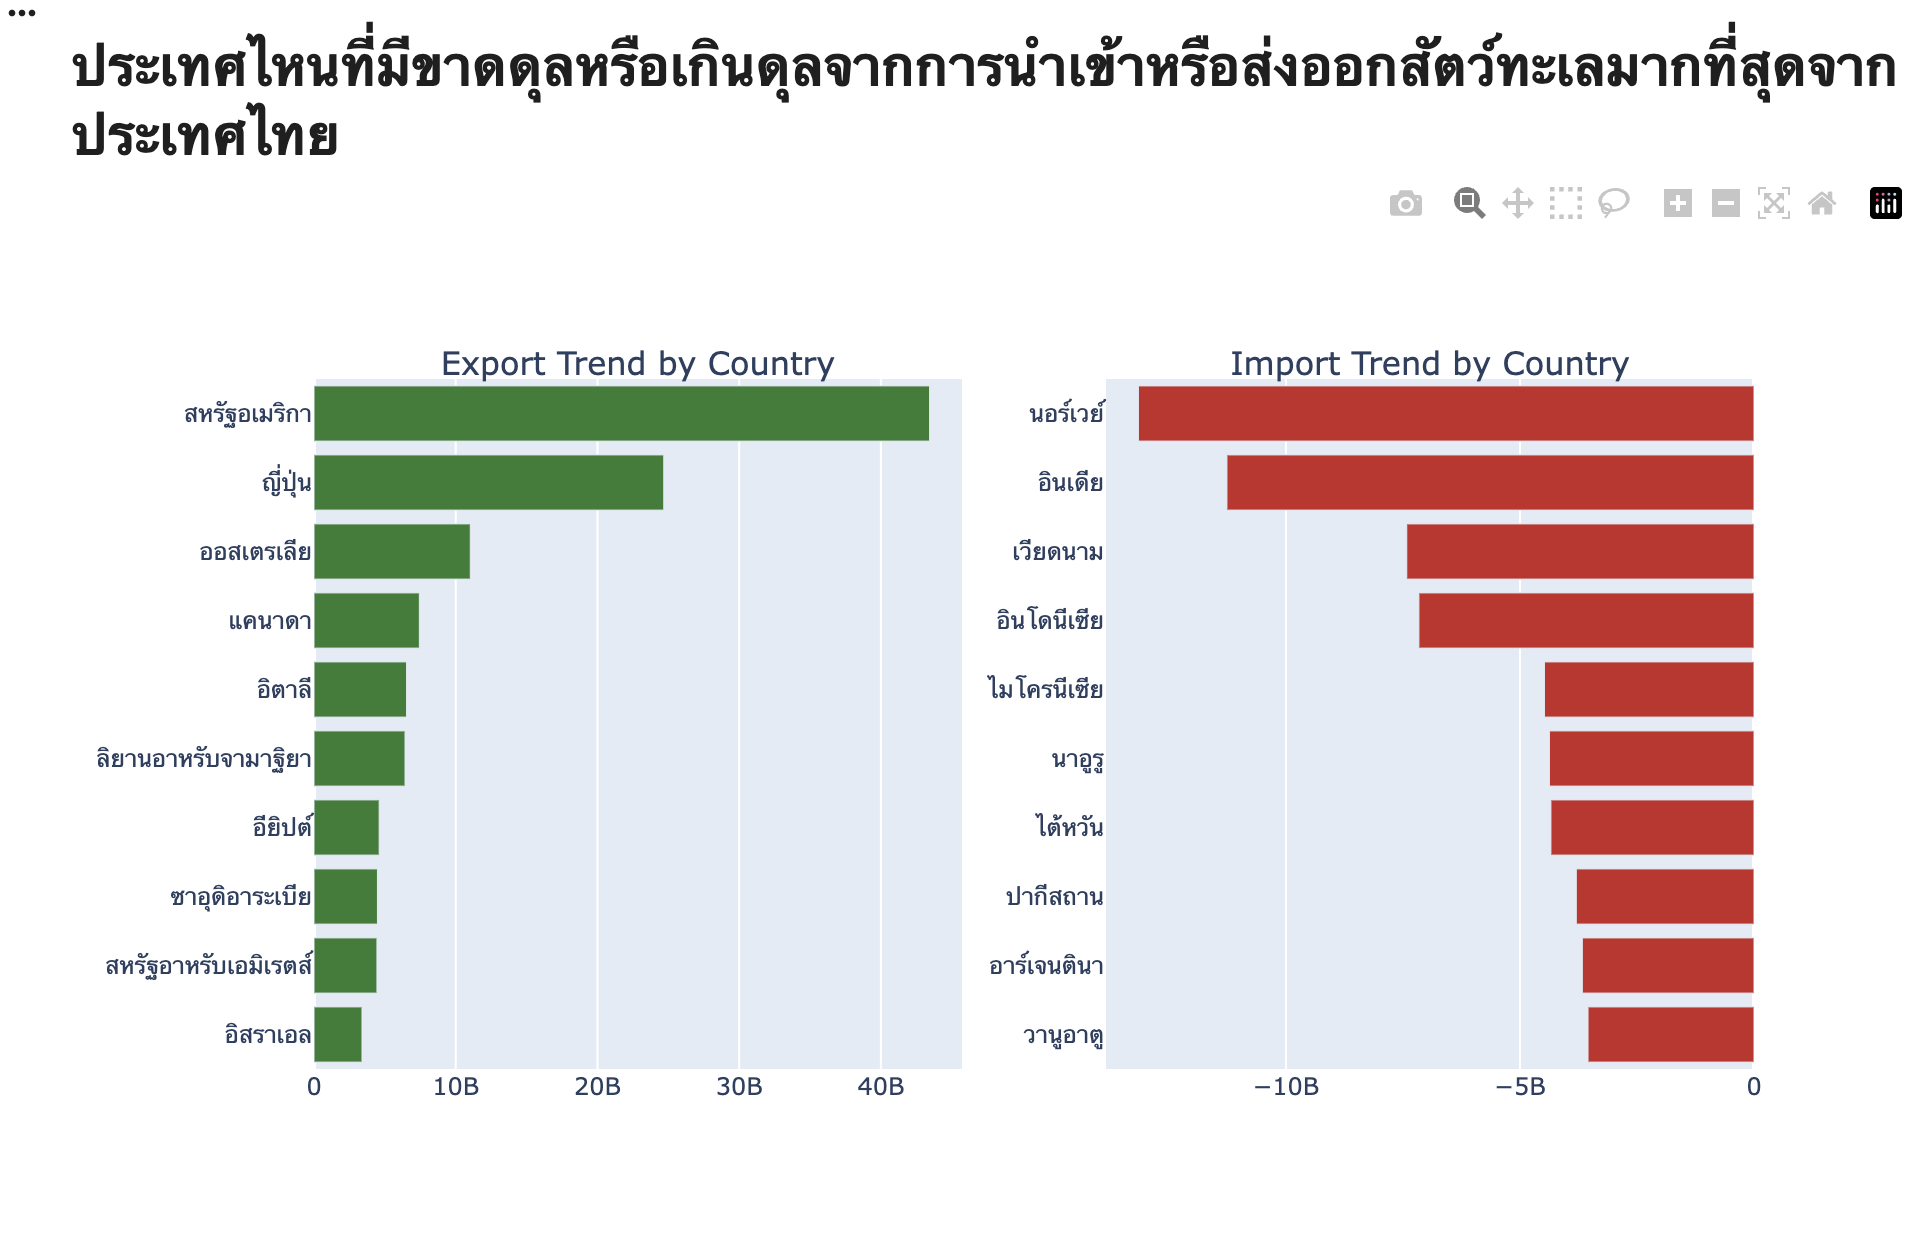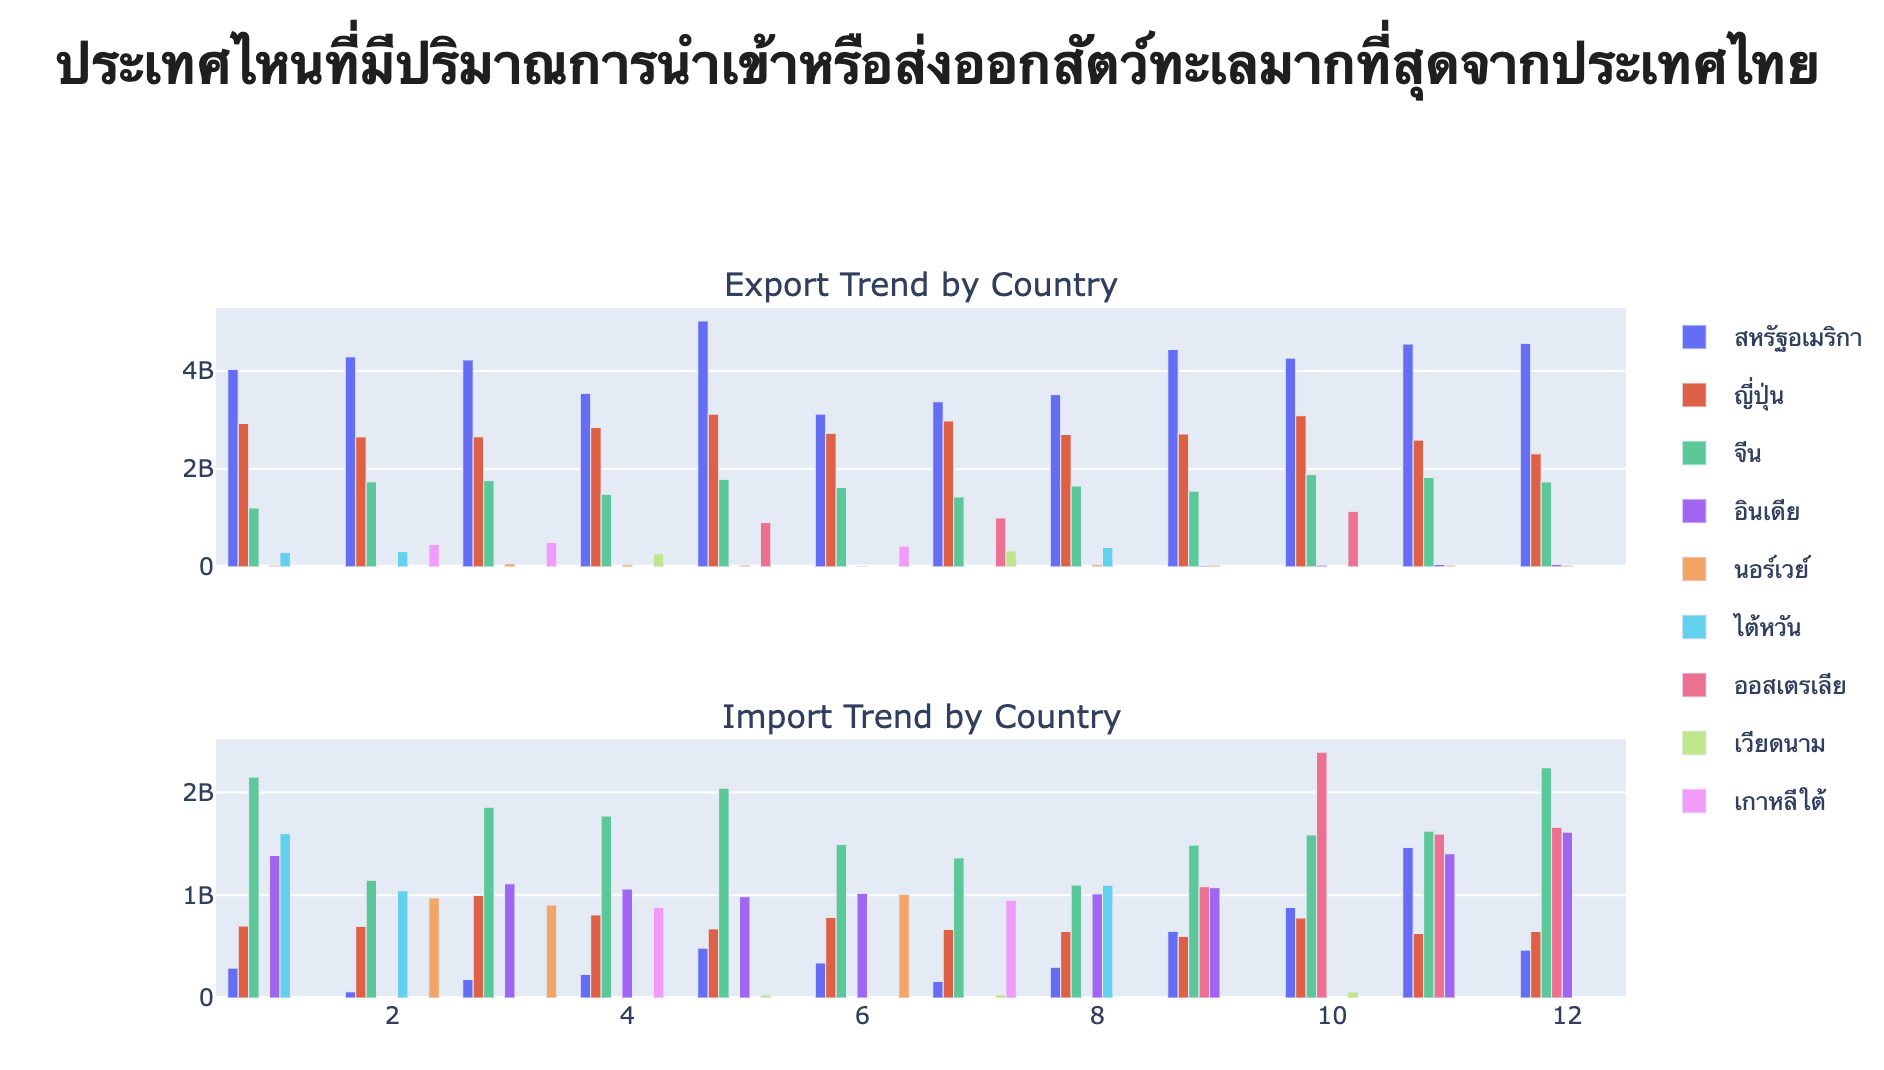

จากข้อมูลเราจะพบว่าไทยเกิยดุลอยู่ที่ประมาณ **70 พันล้านบาท**

ประเทศที่ไทยส่งสินค้าไปให้มากที่สุดคือสหรัฐอเมริกาและรองลงมาคือญี่ปุ่น และยังพบว่าสหรัฐและญี่ปุ่นก็เป็นประเทศที่ทำรายได้ให้กับไทยสูงอย่างต่อเนื่องเช่นเดียวกัน

ส่วนการนำสินค้าเข้ามาจะพบว่าช่วงๆแรกๆไทยมีการนำสินค้าจีนมาตั้งแต่ต้นปี แต่พอช่วงท้ายปีพบว่าได้มีการนำสินค้าจาก อินเดียและนอเวย์มากขึ้น อาจจะเกิดจากสินค้าประเทศจีนไม่เพียงพอ หรือ เกิดการเปลี่ยนคู่ค้าเกิดขึ้น แต่ก็พบว่าสองประเทศดังกล่าวเป็นประเทศที่ขาดดุลการค้ากับประเทศไทยเหมือนกัน อาจจะเพราะมีการนำเข้ามาจำนวนปริมาณมากๆในช่วงท้ายปี แต่จำนวนไม่ได้มากเท่ากับการเกินดุลทางการค้า



# 🦐 Challenge Question 2: สินค้าประมงชนิดใดคือหัวใจของการค้าไทย?


เนื่องจากข้อมูลมีค่า blank เยอะ และ ภาษาอังกฤษมี Other และจากโจทย์เหมือนจะให้แยกสินค้าประมงโดยใช้ HS_code เพื่อแบ่งแยกสัตว์น้ำ และจะเอาคำใส่แทน หากมีค่าที่ต้องการใส่ ค่อยดึงภาษาไทยมาใส่


In [291]:
df.head(10)

year,month,HS_code,countryID,countryNameTH,weight_kg_thousand,quantity,value_thb_million,tradeflow,productDetailTH,trade_type,hs2,hs4,hs6,price_per_weight
i32,i32,str,str,str,f64,i64,f64,i32,str,str,str,str,str,f64
2568,6,"""16041419000""","""EG""","""อียิปต์""",2.171728e6,4261770,1.88245615e8,2,"""ปลาทูน่า สคิปแจกและแอตแลนติกโบ…","""Export""","""16""","""1604""","""160414""",0.00002
2568,5,"""3061721090""","""CY""","""ไซปรัส""",2754.0,2754,999274.0,2,"""กุ้งขาว ไม่มีหัว มีหาง แช่เย็น…","""Export""","""30""","""3061""","""306172""",0.131752
2568,7,"""21039012000""","""CO""","""โคลัมเบีย""",4100.0,400,165655.0,2,"""น้ำปลา""","""Export""","""21""","""2103""","""210390""",0.101009
2568,4,"""3011199090""","""VN""","""เวียดนาม""",120.0,39250,129910.0,2,"""ลูกปลาอื่น ๆ มีชีวิต""","""Export""","""30""","""3011""","""301119""",0.027582
2568,4,"""16041419000""","""LR""","""ลิเบีย""",4488.0,550,516291.0,2,"""ปลาทูน่า สคิปแจกและแอตแลนติกโบ…","""Export""","""16""","""1604""","""160414""",0.20916
2568,12,"""16041419000""","""VU""","""วานูอาตู""",17316.0,17316,1.801692e6,2,"""ปลาทูน่า สคิปแจกและแอตแลนติกโบ…","""Export""","""16""","""1604""","""160414""",0.006009
2568,6,"""3034200000""","""KR""","""เกาหลีใต้""",335669.0,335669,2.0833144e7,1,"""ปลาทูน่าครีบเหลืองแช่เย็นจนแข็…","""Import""","""30""","""3034""","""303420""",0.000185
2568,7,"""16041990000""","""JP""","""ญี่ปุ่น""",14826.0,14826,2.538902e6,2,"""ปลาอื่นๆปรุงแต่ง""","""Export""","""16""","""1604""","""160419""",0.01155
2568,8,"""16055300000""","""RU""","""รัสเซีย""",65632.0,65632,1.0766631e7,2,"""หอยแมลงภู่ ปรุงแต่ง""","""Export""","""16""","""1605""","""160553""",0.002499


## แบ่งหมวดหมู่สินค้า

In [292]:
# ทำการจัดหมวดหมู่สินค้าตามประเภทสินค้าและตามหมวดการค้าขาย
by_product = (
    df.group_by(['hs6','trade_type'])
    .agg([
        pl.col('value_thb_million').sum().alias('total_value'),
        pl.col('weight_kg_thousand').sum().alias('total_weight'),
    ])
    .sort(['hs6', 'trade_type'])
)

by_product

hs6,trade_type,total_value,total_weight
str,str,f64,f64
"""106200""","""Export""",1.016348e6,3818.0
"""106200""","""Import""",4.331948e6,4201.0
"""106900""","""Export""",2.4843834e7,368566.0
"""121221""","""Export""",1.06627857e8,381174.0
"""121221""","""Import""",2.4231e9,4.516641e6
…,…,…,…
"""511913""","""Import""",880702.0,27681.0
"""511919""","""Export""",6.3701477e7,1.734377e6
"""511919""","""Import""",1.16019569e8,2.0854651e7


In [293]:
# ทำการ pivot ข้อมูลให้ง่ายต่อการนำไปใช้งาน
pivot_by_product = (
    by_product
    .pivot(
        values=["total_value", "total_weight"],
        index="hs6",
        columns="trade_type"
    )
    .fill_null(0)
)
pivot_by_product

hs6,total_value_Export,total_value_Import,total_weight_Export,total_weight_Import
str,f64,f64,f64,f64
"""106200""",1.016348e6,4.331948e6,3818.0,4201.0
"""106900""",2.4843834e7,0.0,368566.0,0.0
"""121221""",1.06627857e8,2.4231e9,381174.0,4.516641e6
"""121229""",35738.0,7.656939e6,272.0,284180.0
"""130231""",5.9034799e7,3.43857925e8,72812.0,663932.0
…,…,…,…,…
"""511911""",2675.0,200954.0,1.0,1.0
"""511912""",6.34087509e8,9.47523719e8,408942.0,999274.0
"""511913""",8146.0,880702.0,17.0,27681.0


In [294]:
# สร้าง net ของแต่ละหมวดหมู่
pivot_by_product = pivot_by_product.with_columns([
    (pl.col("total_value_Export") - pl.col("total_value_Import")).alias("net_ex_value"),
    (pl.col("total_weight_Export") - pl.col("total_weight_Import")).alias("net_ex_weight"),
    (pl.col("total_value_Import") - pl.col("total_value_Export")).alias("net_im_value"),
    (pl.col("total_weight_Import") - pl.col("total_weight_Export")).alias("net_im_weight")
])
pivot_by_product

hs6,total_value_Export,total_value_Import,total_weight_Export,total_weight_Import,net_ex_value,net_ex_weight,net_im_value,net_im_weight
str,f64,f64,f64,f64,f64,f64,f64,f64
"""106200""",1.016348e6,4.331948e6,3818.0,4201.0,-3.3156e6,-383.0,3.3156e6,383.0
"""106900""",2.4843834e7,0.0,368566.0,0.0,2.4843834e7,368566.0,-2.4843834e7,-368566.0
"""121221""",1.06627857e8,2.4231e9,381174.0,4.516641e6,-2.3164e9,-4.135467e6,2.3164e9,4.135467e6
"""121229""",35738.0,7.656939e6,272.0,284180.0,-7.621201e6,-283908.0,7.621201e6,283908.0
"""130231""",5.9034799e7,3.43857925e8,72812.0,663932.0,-2.8482e8,-591120.0,2.84823126e8,591120.0
…,…,…,…,…,…,…,…,…
"""511911""",2675.0,200954.0,1.0,1.0,-198279.0,0.0,198279.0,0.0
"""511912""",6.34087509e8,9.47523719e8,408942.0,999274.0,-3.1344e8,-590332.0,3.1343621e8,590332.0
"""511913""",8146.0,880702.0,17.0,27681.0,-872556.0,-27664.0,872556.0,27664.0


In [295]:
# แยกข้อมูลแค่การนำเข้าสินค้า ดูว่าโดยรวมเเล้วสินค้านั้นมีกำไรการนำเข้า และ ปริมาณการนำเข้าสุทธิเท่าไหร่
net_import = pivot_by_product.select(["hs6","net_im_value","net_im_weight"])
net_import

hs6,net_im_value,net_im_weight
str,f64,f64
"""106200""",3.3156e6,383.0
"""106900""",-2.4843834e7,-368566.0
"""121221""",2.3164e9,4.135467e6
"""121229""",7.621201e6,283908.0
"""130231""",2.84823126e8,591120.0
…,…,…
"""511911""",198279.0,0.0
"""511912""",3.1343621e8,590332.0
"""511913""",872556.0,27664.0


In [296]:
# แยกข้อมูลแค่การนำออกสินค้า ดูว่าโดยรวมเเล้วสินค้านั้นมีกำไรการนำออก และ ปริมาณการนำออกสุทธิเท่าไหร่

net_export = pivot_by_product.select(["hs6","net_ex_value","net_ex_weight"])
net_export

hs6,net_ex_value,net_ex_weight
str,f64,f64
"""106200""",-3.3156e6,-383.0
"""106900""",2.4843834e7,368566.0
"""121221""",-2.3164e9,-4.135467e6
"""121229""",-7.621201e6,-283908.0
"""130231""",-2.8482e8,-591120.0
…,…,…
"""511911""",-198279.0,0.0
"""511912""",-3.1344e8,-590332.0
"""511913""",-872556.0,-27664.0


In [297]:
# maping ค่ากับชื่อปลาตามหมวดหมู่
hs6_map = (
    df.select(["hs6", "productDetailTH"])
    .drop_nulls()
    .unique(subset=["hs6"])
)
hs6_map

hs6,productDetailTH
str,str
"""410320""","""หนังดิบอื่น ๆ ของสัตว์เลื่อยคล…"
"""302530""","""ปลาโคล สด แช่เย็น"""
"""307212""","""หอยเชลล์และหอยควีนสแกนลอป สดหร…"
"""302420""","""ปลาแอนโชวี สด แช่เย็น"""
"""306322""","""ลอบสเตอร์อื่น ๆ มีชีวิต"""
…,…
"""160556""","""หอยลาย หอยกาบ และหอยแครง ปรุงแ…"
"""307393""","""หอยแมลงภู่ แห้ง ใส่เกลือหรือแช…"
"""307720""","""หอยลาย หอยกาบ หอยแครง แช่เย็นจ…"


In [298]:
# join ชื่อ import name
net_import_named = net_import.join(
    hs6_map,
    on="hs6",
    how="left"
)
# net_import_named

net_import_named = net_import_named.with_columns(
    pl.when(pl.col("net_im_weight") > 0)
    .then(pl.col("net_im_value") / pl.col("net_im_weight"))
    .otherwise(None)
    .alias("net_im_size")
)

net_import_named

hs6,net_im_value,net_im_weight,productDetailTH,net_im_size
str,f64,f64,str,f64
"""106200""",3.3156e6,383.0,"""ตะพาบน้ำไต้หวันมีชีวิต""",8656.91906
"""106900""",-2.4843834e7,-368566.0,"""กบมีชีวิตสำหรับบริโภคและทำพันธ…",null
"""121221""",2.3164e9,4.135467e6,"""สาหร่ายทะเลและสาหร่ายอื่นๆที่เ…",560.141806
"""121229""",7.621201e6,283908.0,"""เฉพาะสาหร่ายทะเล นําเข้ามาเพื่…",26.843911
"""130231""",2.84823126e8,591120.0,"""วุ้นที่ได้จากสาหร่ายทะเล""",481.836389
…,…,…,…,…
"""511911""",198279.0,0.0,"""สัตว์ในตอนที่3 ที่ไม่มีชีวิต""",null
"""511912""",3.1343621e8,590332.0,"""ไข่ปลา""",530.949042
"""511913""",872556.0,27664.0,"""ไข่ไรน้ำ""",31.541209


In [299]:
# joined ชื่อ export name
net_export_named = net_export.join(
    hs6_map,
    on="hs6",
    how="left"
)
# net_export_named

net_export_named = net_export_named.with_columns(
    pl.when(pl.col("net_ex_weight") > 0)
    .then(pl.col("net_ex_value") / pl.col("net_ex_weight"))
    .otherwise(None)
    .alias("net_ex_size")
)
net_export_named

hs6,net_ex_value,net_ex_weight,productDetailTH,net_ex_size
str,f64,f64,str,f64
"""106200""",-3.3156e6,-383.0,"""ตะพาบน้ำไต้หวันมีชีวิต""",null
"""106900""",2.4843834e7,368566.0,"""กบมีชีวิตสำหรับบริโภคและทำพันธ…",67.406744
"""121221""",-2.3164e9,-4.135467e6,"""สาหร่ายทะเลและสาหร่ายอื่นๆที่เ…",null
"""121229""",-7.621201e6,-283908.0,"""เฉพาะสาหร่ายทะเล นําเข้ามาเพื่…",null
"""130231""",-2.8482e8,-591120.0,"""วุ้นที่ได้จากสาหร่ายทะเล""",null
…,…,…,…,…
"""511911""",-198279.0,0.0,"""สัตว์ในตอนที่3 ที่ไม่มีชีวิต""",null
"""511912""",-3.1344e8,-590332.0,"""ไข่ปลา""",null
"""511913""",-872556.0,-27664.0,"""ไข่ไรน้ำ""",null


In [300]:
# #
# # df_plot = net_export_named.to_pandas()
# # df_plot = df_plot.sort_values("net_ex_value", ascending=True).head(10)


# df_plot = (
#     net_export_named
#     .to_pandas()
#     .sort_values("net_ex_value", ascending=False)
#     .head(10)
#     .sort_values("net_ex_value", ascending=True)
# )
# # df_plot
# fig = px.bar(
#     df_plot,
#     x="net_ex_value",
#     y="productDetailTH",
#     # barmode="group",
#     orientation="h",
#     title="สินค้าที่ไทย ที่ไทยทำการส่งออกมากกว่า",
#     labels={
#         "net_trade": "ดุลการค้า (ล้านบาท)",
#         "countryNameTH": "ประเทศ"
#     }

# )

# # ตั้งสีเดียว
# fig.update_traces(marker_color="#2E7D32")

# # # เส้นแบ่ง 0
# # fig.add_vline(x=0, line_dash="dash", line_color="black")


# fig.show()




In [301]:

# df_plot = (
#     net_export_named
#     .to_pandas()
#     .sort_values("net_ex_weight", ascending=False)
#     .head(10)
#     .sort_values("net_ex_weight", ascending=True)
# )
# # df_plot
# fig = px.bar(
#     df_plot,
#     x="net_ex_weight",
#     y="productDetailTH",
#     # barmode="group",
#     orientation="h",
#     title="สินค้าที่ไทย ที่ไทยทำการส่งออกมากกว่า",
#     labels={
#         "net_trade": "ดุลการค้า (ล้านบาท)",
#         "countryNameTH": "ประเทศ"
#     }

# )

# # ตั้งสีเดียว
# fig.update_traces(marker_color="#2E7D32")


# fig.show()

In [302]:
# df_plot = (
#     net_export_named
#     .to_pandas()
#     .sort_values("net_ex_size", ascending=False)
#     .head(10)
#     .sort_values("net_ex_size", ascending=True)
# )
# # df_plot
# fig = px.bar(
#     df_plot,
#     x="net_ex_size",
#     y="productDetailTH",
#     # barmode="group",
#     orientation="h",
#     title="สินค้าที่ไทย ที่ไทยทำการส่งออกมากกว่า",
#     labels={
#         "net_trade": "ดุลการค้า (ล้านบาท)",
#         "countryNameTH": "ประเทศ",
#         "net_ex_weight" : "น้ำหนัก",
#         "net_ex_value" : "ราคาที่ขายไป",
#     }

# )

# # ตั้งสีเดียว
# fig.update_traces(marker_color="#2E7D32")

# fig.show()

## ดูสินค้าประมงที่มีการส่งออกมากที่สุด

In [303]:
# เตรียม data
df_value = (
    net_export_named
    .to_pandas()
    .sort_values("net_ex_value", ascending=False)
    .head(10)
    .sort_values("net_ex_value", ascending=True)
)

df_weight = (
    net_export_named
    .to_pandas()
    .sort_values("net_ex_weight", ascending=False)
    .head(10)
    .sort_values("net_ex_weight", ascending=True)
)

df_size = (
    net_export_named
    .to_pandas()
    .sort_values("net_ex_size", ascending=False)
    .head(10)
    .sort_values("net_ex_size", ascending=True)
)

# 🔥 สร้าง subplot
fig = make_subplots(
    rows=3, cols=1,
    subplot_titles=[
        "Top Export Value",
        "Top Export Weight",
        "Top Unit Value"
    ]
)

#  กราฟ 1: Value
fig.add_trace(
    go.Bar(
        x=df_value["net_ex_value"],
        y=df_value["productDetailTH"],
        orientation="h",
        marker_color="#2E7D32",
        name="Value"
    ),
    row=1, col=1
)

#  กราฟ 2: Weight
fig.add_trace(
    go.Bar(
        x=df_weight["net_ex_weight"],
        y=df_weight["productDetailTH"],
        orientation="h",
        marker_color="#2E7D32",
        name="Weight"
    ),
    row=2, col=1
)

#  กราฟ 3: Size
fig.add_trace(
    go.Bar(
        x=df_size["net_ex_size"],
        y=df_size["productDetailTH"],
        orientation="h",
        marker_color="#66BB6A",
        name="Unit Value"
    ),
    row=3, col=1
)

# layout
fig.update_layout(
    title="สินค้าที่มการส่งออกมากที่สุดในไทย (ปี 2568) โดยแบ่งหมวดหมู่เป็น มูลค่า น้ำหนัก และ ราคาต่อหน่วย",
    height=1000,
    showlegend=False
)

fig.show()

## ดูสินค้าประมงที่มีการนำเข้ามากที่สุด

In [304]:
# เตรียม data
df_value = (
    net_import_named
    .to_pandas()
    .sort_values("net_im_value", ascending=False)
    .head(10)
    .sort_values("net_im_value", ascending=True)
)

df_weight = (
    net_import_named
    .to_pandas()
    .sort_values("net_im_weight", ascending=False)
    .head(10)
    .sort_values("net_im_weight", ascending=True)
)

df_size = (
    net_import_named
    .to_pandas()
    .sort_values("net_im_size", ascending=False)
    .head(10)
    .sort_values("net_im_size", ascending=True)
)

# สร้าง subplot
fig = make_subplots(
    rows=3, cols=1,
    subplot_titles=[
        "Top Import Value",
        "Top Import Weight",
        "Top Unit Value"
    ]
)

#  กราฟ 1: Value
fig.add_trace(
    go.Bar(
        x=df_value["net_im_value"],
        y=df_value["productDetailTH"],
        orientation="h",
        marker_color="#C62828",
        name="Value"
    ),
    row=1, col=1
)

#  กราฟ 2: Weight
fig.add_trace(
    go.Bar(
        x=df_weight["net_im_weight"],
        y=df_weight["productDetailTH"],
        orientation="h",
        marker_color="#C62828",
        name="Weight"
    ),
    row=2, col=1
)

#  กราฟ 3: Size
fig.add_trace(
    go.Bar(
        x=df_size["net_im_size"],
        y=df_size["productDetailTH"],
        orientation="h",
        marker_color="#FF8A65",
        name="Unit Value"
    ),
    row=3, col=1
)

# layout
fig.update_layout(
    title="สินค้าที่มการนำเข้ามากที่สุดในไทย (ปี 2568) โดยแบ่งหมวดหมู่เป็น มูลค่า น้ำหนัก และ ราคาต่อหน่วย",
    height=1000,
    showlegend=False
)
# display(HTML('<h1>มูลค่า และปริมาณสินค้าประมงแนวโน้มการเปลี่ยนแปลง ตามรายเดือน (ปี 2568)</h1>'))

fig.show()

### สรุปคร่าวๆจากข้อมูลที่พบ
จากการวิเคราะห์ข้อมูลการค้าระหว่างประเทศ พบว่า **ปลาทูน่า และ อาหารสุนัขและแมว**
เป็นสินค้าหลักที่ประเทศไทยส่งออกมากที่สุด ทั้งในแง่ปริมาณและมูลค่า โดยถือเป็นสินค้าที่สร้างรายได้สำคัญให้กับประเทศอย่างต่อเนื่อง อย่างไรก็ตาม เมื่อพิจารณาในเชิง มูลค่าต่อหน่วย พบว่า **สัตว์ไม่มีกระดูกสันหลังอื่น ๆ **เป็นกลุ่มสินค้าที่สามารถจำหน่ายได้ในราคาสูงกว่าสินค้าประเภทอื่น

ในด้านการนำเข้า ประเทศไทยมีการนำเข้า **ปลาสคิปแจ็ค** ในปริมาณสูงที่สุด และยังมีมูลค่าการนำเข้าสูงเป็นอันดับหนึ่งเช่นกัน รองลงมาคือ **ปลาอินเดียนแมคเคอเรล** ซึ่งมีปริมาณการนำเข้าในระดับสูง อย่างไรก็ตาม หากพิจารณาในเชิง ราคาต่อหน่วย จะพบว่า** คาเวียร์ **เป็นสินค้าที่มีมูลค่าต่อหน่วยสูงที่สุดในกลุ่มสินค้านำเข้า

# 📈 Challenge Question 3: การค้าสัตว์น้ำมีฤดูกาลหรือไม่?

In [305]:
df

year,month,HS_code,countryID,countryNameTH,weight_kg_thousand,quantity,value_thb_million,tradeflow,productDetailTH,trade_type,hs2,hs4,hs6,price_per_weight
i32,i32,str,str,str,f64,i64,f64,i32,str,str,str,str,str,f64
2568,6,"""16041419000""","""EG""","""อียิปต์""",2.171728e6,4261770,1.88245615e8,2,"""ปลาทูน่า สคิปแจกและแอตแลนติกโบ…","""Export""","""16""","""1604""","""160414""",0.00002
2568,5,"""3061721090""","""CY""","""ไซปรัส""",2754.0,2754,999274.0,2,"""กุ้งขาว ไม่มีหัว มีหาง แช่เย็น…","""Export""","""30""","""3061""","""306172""",0.131752
2568,7,"""21039012000""","""CO""","""โคลัมเบีย""",4100.0,400,165655.0,2,"""น้ำปลา""","""Export""","""21""","""2103""","""210390""",0.101009
2568,4,"""3011199090""","""VN""","""เวียดนาม""",120.0,39250,129910.0,2,"""ลูกปลาอื่น ๆ มีชีวิต""","""Export""","""30""","""3011""","""301119""",0.027582
2568,4,"""16041419000""","""LR""","""ลิเบีย""",4488.0,550,516291.0,2,"""ปลาทูน่า สคิปแจกและแอตแลนติกโบ…","""Export""","""16""","""1604""","""160414""",0.20916
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
2568,6,"""23012010000""","""IT""","""อิตาลี""",40000.0,40000,1.428279e6,2,"""ปลาป่นที่มีโปรตีนน้อยกว่าร้อยล…","""Export""","""23""","""2301""","""230120""",0.000893
2568,1,"""23091010001""","""SG""","""สิงคโปร์""",5141.0,3060,957188.0,2,"""อาหารสุนัขหรือแมวที่มีปลาบรรจุ…","""Export""","""23""","""2309""","""230910""",0.060845
2568,1,"""16041311000""","""GT""","""กัวเตมาลา""",164141.0,12442,1.1653066e7,2,"""ปลาซาร์ดีน ซาร์ดีนเนลล่าและปลา…","""Export""","""16""","""1604""","""160413""",0.005706


## แยกข้อมูลออกเป็นตามรายเดือน


In [306]:
#แยกตามรายเดือน แบ่งเป็น import export
monthly = (
    df.group_by(['month', 'trade_type'])
    .agg([
        pl.col('value_thb_million').sum().alias('total_value'),
        pl.col('weight_kg_thousand').sum().alias('total_weight'),
        # pl.len().alias('n_records'),
    ])
    .sort(['trade_type', 'month'])
)
monthly

month,trade_type,total_value,total_weight
i32,str,f64,f64
1,"""Export""",1.7793e10,1.34471219e8
2,"""Export""",1.8700e10,1.44913848e8
3,"""Export""",1.8706e10,1.44791463e8
4,"""Export""",1.7180e10,1.3089182e8
5,"""Export""",2.0028e10,1.48084134e8
…,…,…,…
8,"""Import""",1.0164e10,1.40807943e8
9,"""Import""",1.1591e10,1.55457688e8
10,"""Import""",1.3472e10,1.90439074e8


In [307]:
# mapping ชื่อเดือน
df_plot = monthly.to_pandas()

month_names = {1:'ม.ค.',2:'ก.พ.',3:'มี.ค.',4:'เม.ย.',5:'พ.ค.',6:'มิ.ย.',
               7:'ก.ค.',8:'ส.ค.',9:'ก.ย.',10:'ต.ค.',11:'พ.ย.',12:'ธ.ค.'}
df_plot['month_name'] = df_plot['month'].map(month_names)
df_plot

,month,trade_type,total_value,total_weight,month_name
0,1,Export,1.779335e+10,134471219.0,ม.ค.
1,2,Export,1.870039e+10,144913848.0,ก.พ.
2,3,Export,1.870597e+10,144791463.0,มี.ค.
3,4,Export,1.717999e+10,130891820.0,เม.ย.
4,5,Export,2.002802e+10,148084134.0,พ.ค.
5,6,Export,1.709186e+10,129787349.0,มิ.ย.
6,7,Export,1.852238e+10,138124952.0,ก.ค.
7,8,Export,1.815404e+10,136402809.0,ส.ค.
8,9,Export,1.939407e+10,138797271.0,ก.ย.
9,10,Export,1.994654e+10,147404468.0,ต.ค.


In [308]:
# สร้าง subplot 2 แถว
fig = make_subplots(
    rows=2, cols=1,
    shared_xaxes=True,
    subplot_titles=[
        '<b>มูลค่าการค้าสินค้าประมงรายเดือนประจำปี 2568 โดยดูภาพรวมราคาการส่งออกและนำเข้า</b><br><sup>Hover เพื่อดูรายละเอียด | มองหาเดือน Peak / Low</sup>',
        '<b>ปริมาณการค้าสินค้าประมงรายเดือนประจำปี 2568 โดยดูภาพรวมปริมาณการส่งออกและนำเข้า</b><br><sup>Hover เพื่อดูรายละเอียด | มองหาเดือน Peak / Low</sup>']
)
# กราฟที่ 1: value
fig1 = px.line(
    df_plot,
    x='month',
    y='total_value',
    color='trade_type',
    markers=True,
    color_discrete_map={'Export': '#2E7D32', 'Import': '#C62828'}


)

# กราฟที่ 2: weight
fig2 = px.line(
    df_plot,
    x='month',
    y='total_weight',
    color='trade_type',
    markers=True,
    color_discrete_map={'Export': '#2E7D32', 'Import': '#C62828'}

)

# เอา trace จากแต่ละกราฟมาใส่
for trace in fig1.data:
    fig.add_trace(trace, row=1, col=1)

for trace in fig2.data:
    trace.showlegend = False
    fig.add_trace(trace, row=2, col=1)



display(HTML('<h1>มูลค่า และปริมาณสินค้าประมงแนวโน้มการเปลี่ยนแปลง ตามรายเดือน (ปี 2568)</h1>'))
display(HTML('<h2>เพื่อดูแนวโน้มการนำเข้าและส่งออกสินค้าประมง ปี 2568</h2>'))
fig.show()

In [309]:
# ดูว่ามากสุดคือเดือนไหน หรือน้อยสุดคือเดือนไหน และราคาเท่าไหร่
ex_monthly = df_plot[df_plot['trade_type'] == 'Export']
im_monthly = df_plot[df_plot['trade_type'] == 'Import']

ex_peak = ex_monthly.loc[ex_monthly['total_value'].idxmax()]
ex_peak_weight = ex_monthly.loc[ex_monthly['total_weight'].idxmax()]

ex_low  = ex_monthly.loc[ex_monthly['total_value'].idxmin()]
ex_low_weight  = ex_monthly.loc[ex_monthly['total_weight'].idxmin()]

im_peak = im_monthly.loc[im_monthly['total_value'].idxmax()]
im_peak_weight = im_monthly.loc[im_monthly['total_weight'].idxmax()]

im_low  = im_monthly.loc[im_monthly['total_value'].idxmin()]
im_low_weight  = im_monthly.loc[im_monthly['total_weight'].idxmin()]

print(f'Export Peak Price : {ex_peak["month_name"]} ({ex_peak["total_value"]:,.1f} ล้านบาท)')
print(f'Export Peak Weight" : {ex_peak_weight["month_name"]} ({ex_peak_weight["total_weight"]:,.1f}  พัน กิโลกรัม)')
print("-"*60)
print(f'Export Low Price : {ex_low["month_name"]}  ({ex_low["total_value"]:,.1f} ล้านบาท)')
print(f'Export Low Weight : {ex_low_weight["month_name"]}  ({ex_low_weight["total_weight"]:,.1f}  พัน กิโลกรัม)')

print("="*60)
print(f'Import Peak Price : {im_peak["month_name"]}  ({im_peak["total_value"]:,.1f} ล้านบาท)')
print(f'Import Peak Weight : {im_peak_weight["month_name"]}  ({im_peak_weight["total_weight"]:,.1f} พัน กิโลกรัม)')
print("-"*60)
print(f'Import Low  Price : {im_low["month_name"]}  ({im_low["total_value"]:,.1f} ล้านบาท)')
print(f'Import Low Weight : {im_low_weight["month_name"]}  ({im_low_weight["total_weight"]:,.1f}  พัน กิโลกรัม)')

Export Peak Price : พ.ค. (20,028,024,450.6 ล้านบาท)
Export Peak Weight" : พ.ค. (148,084,134.0  พัน กิโลกรัม)
------------------------------------------------------------
Export Low Price : มิ.ย.  (17,091,855,534.0 ล้านบาท)
Export Low Weight : มิ.ย.  (129,787,349.0  พัน กิโลกรัม)
Import Peak Price : ม.ค.  (15,317,645,278.0 ล้านบาท)
Import Peak Weight : ม.ค.  (218,362,502.0 พัน กิโลกรัม)
------------------------------------------------------------
Import Low  Price : ส.ค.  (10,164,168,004.0 ล้านบาท)
Import Low Weight : ก.ค.  (135,976,842.0  พัน กิโลกรัม)


In [310]:
# แบ่ง product ตามรายเดือน และ แบ่งเป็นการนำเข้าและส่งออก
monthy_product = (
    df.group_by(['hs6','month','trade_type'])
    .agg([
        pl.col('value_thb_million').sum().alias('total_value'),
        pl.col('weight_kg_thousand').sum().alias('total_weight'),
    ])
    .sort(['hs6','month','trade_type'])
)
monthy_product

hs6,month,trade_type,total_value,total_weight
str,i32,str,f64,f64
"""106200""",1,"""Export""",97277.0,24.0
"""106200""",1,"""Import""",169196.0,200.0
"""106200""",2,"""Export""",3870.0,1.0
"""106200""",2,"""Import""",717076.0,520.0
"""106200""",3,"""Export""",10809.0,12.0
…,…,…,…,…
"""511993""",10,"""Import""",27411.0,5.0
"""511993""",11,"""Export""",6905.0,9.0
"""511993""",11,"""Import""",33814.0,6.0


In [311]:
# แยกไว้สำหรับผลิตภัณฑ์การส่งออก
monthy_product_export = monthy_product.filter(
    pl.col('trade_type') == 'Export'
)
monthy_product_export

hs6,month,trade_type,total_value,total_weight
str,i32,str,f64,f64
"""106200""",1,"""Export""",97277.0,24.0
"""106200""",2,"""Export""",3870.0,1.0
"""106200""",3,"""Export""",10809.0,12.0
"""106200""",4,"""Export""",850.0,2.0
"""106200""",5,"""Export""",37682.0,6.0
…,…,…,…,…
"""511993""",8,"""Export""",448.0,2.0
"""511993""",9,"""Export""",49733.0,39.0
"""511993""",10,"""Export""",326.0,2.0


## ดูการส่งออกสินค้าประมง

In [312]:
# ประเทศที่มีการค้าขายมากที่สุด 10 อันดับแรก เพื่อไม่ให้ข้อมูลเยอะเกิน
top_products = (
    monthy_product_export
    .group_by("hs6")
    .agg(pl.col("total_value").sum())
    .sort("total_value", descending=True)
    .head(10)
    .select("hs6")
    .to_series()
    .to_list()
)

top_products

['160414',
 '230910',
 '306172',
 '210390',
 '160420',
 '160529',
 '160521',
 '307431',
 '160413',
 '230120']

In [313]:
# สร้างกราฟ
monthy_product_export = monthy_product_export.join(
    hs6_map,
    on="hs6",
    how="left"
)
df_plot = monthy_product_export.filter(
    pl.col("hs6").is_in(top_products)
).to_pandas()


fig = px.line(
    df_plot,
    x='month',
    y='total_value',
    color='productDetailTH',
    markers=True,
    hover_name="productDetailTH"
)

fig.update_traces(marker_color="#2E7D32")

display(HTML('<h1>มูลค่าสินค้าที่ทำการส่งออกของประเทศไทย ตามรายเดือน (ปี 2568)</h1>'))
display(HTML('<h2>10 อันดับแรก</h2>'))

fig.show()

In [314]:
df_plot

,hs6,month,trade_type,total_value,total_weight,productDetailTH
0,160413,1,Export,368708380.0,4224446.0,ปลาซาร์ดีน ซาร์ดีนเนลล่าและปลาบริสลิงหรือปลาสแ...
1,160413,2,Export,404715011.0,4778423.0,ปลาซาร์ดีน ซาร์ดีนเนลล่าและปลาบริสลิงหรือปลาสแ...
2,160413,3,Export,368846020.0,4160575.0,ปลาซาร์ดีน ซาร์ดีนเนลล่าและปลาบริสลิงหรือปลาสแ...
3,160413,4,Export,372653891.0,4292820.0,ปลาซาร์ดีน ซาร์ดีนเนลล่าและปลาบริสลิงหรือปลาสแ...
4,160413,5,Export,400091908.0,4811958.0,ปลาซาร์ดีน ซาร์ดีนเนลล่าและปลาบริสลิงหรือปลาสแ...
...,...,...,...,...,...,...
115,307431,8,Export,351550775.0,1379156.0,ปลาหมึกกล้วย แช่เย็นจนแข็ง
116,307431,9,Export,473725125.0,1472439.0,ปลาหมึกกล้วย แช่เย็นจนแข็ง
117,307431,10,Export,598975621.0,1897356.0,ปลาหมึกกล้วย แช่เย็นจนแข็ง
118,307431,11,Export,552635243.0,1821434.0,ปลาหมึกกล้วย แช่เย็นจนแข็ง


In [315]:
# สร้าง subplot 2 แถว
fig = make_subplots(
    rows=2, cols=1,
    shared_xaxes=True,
    subplot_titles=[
        '<b>มูลค่าสินค้าที่มีการส่งออกตามรายเดือน (ปี 2568)</b>',
        '<b>นำหนักสินค้าที่มีการส่งออกตามรายเดือน (ปี 2568)</b>']
)
# กราฟที่ 1: value
fig1 = px.line(
    df_plot,
    x='month',
    y='total_value',
    color='productDetailTH',
    markers=True,
    hover_name="productDetailTH"
)

# กราฟที่ 2: weight
fig2 = px.line(
    df_plot,
    x='month',
    y='total_weight',
    color='productDetailTH',
    markers=True,
    hover_name="productDetailTH"
)


# 🔥 เอา trace จากแต่ละกราฟมาใส่
for trace in fig1.data:
    fig.add_trace(trace, row=1, col=1)

for trace in fig2.data:
    trace.showlegend = False  # ไม่ให้ legend ซ้ำ
    fig.add_trace(trace, row=2, col=1)

display(HTML('<h1>มูลค่า และ น้ำหนักสินค้าที่ทำการส่งออกของประเทศไทย ตามรายเดือน (ปี 2568)</h1>'))
display(HTML('<h2>10 อันดับแรก</h2>'))
fig.show()

#### สรุปคร่าวๆของการส่งออก
จากการวิเคราะห์ข้อมูลรายเดือน พบว่า
ประเทศไทยมีมูลค่าการส่งออกสูงสุดทั้งในด้านราคาและน้ำหนักในเดือนพฤษภาคม และต่ำสุดในเดือนมิถุนายน โดยแนวโน้มดังกล่าวมีความสัมพันธ์อย่างชัดเจนกับสินค้าหลักของประเทศคือ ปลาทูน่า

เนื่องจากปลาทูน่าเป็นสินค้า Export Driver หลัก ของประเทศไทย การเปลี่ยนแปลงของปริมาณส่งออกปลาทูน่าจึงส่งผลโดยตรงต่อภาพรวมการส่งออกทั้งหมด

- เมื่อการส่งออกปลาทูน่าเพิ่มขึ้น → มูลค่าการส่งออกรวมของประเทศเพิ่มขึ้น

- เมื่อการส่งออกปลาทูน่าลดลง → มูลค่าการส่งออกรวมลดลงตาม

จากที่หาข้อมูลเพิ่มเติมพบว่าพบว่าฤดูจับหลักอยู่ในช่วง พฤศจิกายน–เมษายน เลยคาดว่าส่งผลให้เดือนพฤษภาคมมีการส่งออกที่มากสุด พอผ่านไปปลาหมด เลยอยู่ในช่วงพักฟื้น

## ดูการนำเข้าสินค้าประมง

In [316]:
# สินค้าแยกตามหมวดหมู่ รายเดือน และประเทศ และทำการเลือกเฉพาะสินค้าที่มีการนำเข้าอย่างเดียว
monthy_product_import = (
    df.group_by(['hs6','month','trade_type','countryNameTH'])
    .agg([
        pl.col('value_thb_million').sum().alias('total_value'),
        pl.col('weight_kg_thousand').sum().alias('total_weight'),
    ])
    .sort(['hs6','month','trade_type','countryNameTH'])
)

monthy_product_import = monthy_product_import.filter(
    pl.col("trade_type") == "Import"
)
monthy_product_import

hs6,month,trade_type,countryNameTH,total_value,total_weight
str,i32,str,str,f64,f64
"""106200""",1,"""Import""","""เซเชลส์""",169196.0,200.0
"""106200""",2,"""Import""","""มอริเชียส""",113903.0,20.0
"""106200""",2,"""Import""","""เคนยา""",39490.0,25.0
"""106200""",2,"""Import""","""เซเชลส์""",417638.0,420.0
"""106200""",2,"""Import""","""เบนิน""",17170.0,10.0
…,…,…,…,…,…
"""511993""",9,"""Import""","""กรีซ""",891768.0,61.0
"""511993""",10,"""Import""","""กรีซ""",27411.0,5.0
"""511993""",11,"""Import""","""กรีซ""",33814.0,6.0


In [317]:
top_products = (
    monthy_product_import
    .group_by("hs6")
    .agg(pl.col("total_value").sum())
    .sort("total_value", descending=True)
    .head(5)
    .select("hs6")
    .to_series()
    .to_list()
)

top_products

['303430', '307431', '160414', '303420', '303591']

In [318]:
top_countries = (
    monthy_product_import
    .group_by("countryNameTH")
    .agg(pl.col("total_value").sum())
    .sort("total_value", descending=True)
    .head(5)
    .select("countryNameTH")
    .to_series()
    .to_list()
)
top_countries


['จีน', 'นอร์เวย์', 'อินเดีย', 'เวียดนาม', 'ไต้หวัน']

In [319]:
monthy_product_import = monthy_product_import.join(
    hs6_map,
    on="hs6",
    how="left"
)

df_plot = monthy_product_import.filter(
    pl.col("hs6").is_in(top_products) &
    pl.col("countryNameTH").is_in(top_countries)
).to_pandas()

In [320]:
fig = px.line(
    df_plot,
    x="month",
    y="total_value",
    color="productDetailTH",
    facet_col="countryNameTH",
    facet_col_wrap=2,
    markers=True,
    title="Import Trend by Product and Country",
    labels={
        "month": "เดือน",
        "total_value": "มูลค่า (ล้านบาท)",
        "productDetailTH": "สินค้า",
        "countryNameTH": "ประเทศ"
    }
)

display(HTML('<h1>มูลค่าสินค้าที่ทำการเข้าของประเทศไทย ตามรายเดือน (ปี 2568)</h1>'))
display(HTML('<h2>10 อันดับแรก โดยเลือกเฉพาะ 5 ประเทศแรกที่มีสินค้าที่มีการนำเข้ามากที่สุด 5 ชนิด</h2>'))
fig.show()

In [321]:
fig = px.line(
    df_plot,
    x="month",
    y="total_weight",
    color="productDetailTH",
    facet_col="countryNameTH",
    facet_col_wrap=2,
    markers=True,
    title="Import Trend by Product and Country",
    labels={
        "month": "เดือน",
        "total_weight": "น้ำหนัก (พันกก.)",
        "productDetailTH": "สินค้า",
        "countryNameTH": "ประเทศ"
    }
)

display(HTML('<h1>น้ำหนักสินค้าที่ทำการเข้าของประเทศไทย ตามรายเดือน (ปี 2568)</h1>'))
display(HTML('<h2>10 อันดับแรก โดยเลือกเฉพาะ 5 ประเทศแรกที่มีสินค้าที่มีการนำเข้ามากที่สุด 5 ชนิด</h2>'))

fig.show()

#### สรุปคร่าวๆการนำเข้า
จากการวิเคราะห์ข้อมูลรายเดือน พบว่า ประเทศไทยมีมูลค่าการนำเข้าสูงสุดทั้งในด้านราคาและน้ำหนักในมกราคม และต่ำสุดด้านราคาในเดือนสิงหาคม และต่ำสุดในด้านน้ำหนักในกรกฎาคม

การที่ต้นปีมีการนำเข้าที่สูงทั้งสองด้าน แสดงถึงความต้องการมากที่สุดในช่วงต้นปี อาจจะเพราะในปลายปีขายปลา หรืออาจจะรีสตอคเลยอยากจะตุนปลาใหม่ เช่น ปลาทูน่า / ปลาหมึก / ปลาแมคเคอเรล มีการนำเข้าสูงในช่วงต้นปี โดยเฉพาะจาก จีน และไต้หวัน ซึ่งเป็น supplier หลัก และในช่วงปลายปีก็มีการนำเข้าปลาจากอินเดียที่สูงชัดเจน

## ตอบคำถาม

#1. Major Trading Partners

ตลาดส่งออกสินค้าประมงสำคัญของไทย
- อับดับ 1 ประเทศ สหรัฐอเมริกา
- อันดับ 2 ประเทศ ญี่ปุ่น

แหล่งนำเข้าสัตว์น้ำหลักของไทยจะเป็น
- ประเทศจีน ในช่วงต้นปี
- ประเทศอินเดีย ในช่วงท้ายปี

ประเทศที่เกินดุล : สหรัฐฯ และ ญี่ปุ่น

ประเทศที่ขาดดุล : อินเดีย และ นอร์เวย์

#2. Fisheries Product Structure

สินค้าประเภทใดที่ไทยส่งออกมากกว่านำเข้าได้แก่
- **ปลาทูน่ากระป๋องและแปรรูป และอาหารสุนัขและแมว**เป็นอันดับต้นๆ ของรายได้หลัก


สินค้าประเภทใดที่ไทย ต้องพึ่งพาการนำเข้าได้แก่
 - **ปลาสคิปแจ็ค** คาดว่าเป็นวัตถุดิบหลักในการทำทูน่ากระป๋อง ไทยต้องนำเข้ามาเติมเต็มส่วนต่างที่จับเองไม่ได้
- **ปลาอินเดียนแมคเคอเรล** มีการนำเข้าสูงมากๆในช่วงปลายปี

#3. Seasonal Trade Pattern

คิดว่าไม่สามารถระบุได้เลยว่า ข้อมูลที่แสดงเป็น seasonal ไหม เพราะเนื่องจากข้อมูลที่ให้มามีเพียงแค่ปีเดียว ซึ่งถ้าหากจะดู seasonal อาจจะต้องใช้ข้อมูล 4 - 5 ปีเพื่อหา pattern ที่เกิดขึ้นแบบชัดเจน รวมถึงเหตุการณ์ที่มีการนำเข้าประเทศอินเดียมากขึ้นในช่วงท้ายปี เป็นเรื่องบังเอิญหรือต้องการเปลี่ยนคู่ค้าก็ไม่สามารถระบุได้
แต่สามารถสรุปข้อมูลคร่าวๆได้ประมาณนี้

ฝั่ง export
การส่งออกสูงสุดทั้งในด้านราคาและน้ำหนักในเดือนพฤษภาคม และต่ำสุดในเดือนมิถุนายน และ

ฝั่ง import การนำเข้าสูงสุดทั้งในด้านราคาและน้ำหนักในมกราคม และต่ำสุดด้านราคาในเดือนสิงหาคม และต่ำสุดในด้านน้ำหนักในกรกฎาคม


# ประเด็นที่น่าสนใจ

ประเด็นที่น่าสนใจที่สุดคือการที่ไทยเกินดุลการค้าสูงถึง 70,000 ล้านบาท

จากข้อมูลการนำเข้า และการส่งออก คาดว่าไทยไม่ได้รวยจากการจับปลาเอง แต่รวยจากการเป็นแปลงรูปอาหารเเล้วส่งออก เพราะว่าเรายอมขาดดุลกับประเทศที่นำเข้าวัตถุดิบ เช่น ปลาสคิปแจค จากจีน สามารถนำเป็นปลาทูน่าที่เราส่งออกไปขายซึ่งเป็นสินค้าหลักของประเทศเรา และในช่วงท้ายปี ที่มีการเปลี่ยนวัตถุดิบนำเข้าจากจีน เนื่องจากข้อมูลไม่เพียงพอ ไม่เห็นว่าเป็นแนวโน้ม หรือแค่เรื่องบังเอิญที่เกิดขึ้นในปีนี้ จึงไม่ทราบเหตุผลชัดเจนว่า ประเทศจีนปริมาณอาหารไม่เพียง หรือต้องการเปลี่ยนประเทศคู่ค้ากันแน่
